# Transfer Learning: Fine-Tuning Pre-Trained Models

## What This Notebook Is About

Every notebook in this series so far has trained models from scratch — random
weight initialisation, then gradient descent until the model learns useful
representations from the training data. This works well when the dataset is
large enough and the architecture is matched to the task. In practice, both
conditions are often not met.

Transfer learning is the approach used in almost every production deep learning
system. Instead of initialising from random weights, the model starts from
weights learned on a large dataset for a related task. These pre-trained weights
already encode rich representations — edge detectors, texture recognisers, and
object parts for vision models; grammar, semantics, and world knowledge for
language models. Fine-tuning adapts these representations to a new task with
a fraction of the data and compute required to learn them from scratch.

This notebook demonstrates transfer learning in two domains:

**Vision — Oxford Flowers 102**
ResNet18 pre-trained on ImageNet is adapted to classify 102 species of flowers.
ImageNet training exposed the model to 1.2 million images across 1,000 classes.
The learned filters and feature hierarchies transfer directly to flower
classification — a task the model was never explicitly trained on.

**NLP — IMDb Sentiment**
DistilBERT pre-trained on English text is fine-tuned on the same IMDb dataset
used in Notebook 6. This allows a direct comparison: from-scratch Transformer
vs pre-trained Transformer fine-tuned on identical data.

## The Two Modes of Transfer Learning

**Feature extraction** — all pre-trained layers are frozen. Only the new
classification head is trained. The pre-trained model is used as a fixed feature
extractor — it converts raw inputs to rich embeddings that the new head
classifies. Fast to train, requires little data, but limited by the quality of
the pre-trained features for the specific target task.

**Fine-tuning** — some or all pre-trained layers are unfrozen and trained at a
low learning rate alongside the new head. The pre-trained representations are
adapted to the target domain. Slower and requires more data than feature
extraction, but produces significantly better results when the source and target
domains differ.

## What I Want to Understand

- Which layers of a pre-trained CNN carry transferable knowledge and which are
  task-specific?
- How does the accuracy gap between feature extraction, fine-tuning, and
  from-scratch training change with dataset size?
- What do differential learning rates do — and why does the new head need a
  higher rate than the pre-trained layers?
- What does Grad-CAM reveal about which image regions drive the prediction —
  and does a fine-tuned model look at the right parts of the image?
- How large is the accuracy gap between a from-scratch Transformer and a
  fine-tuned DistilBERT on the same 5,000 IMDb samples?
- When should I use feature extraction versus fine-tuning in a real project?

## Datasets and Models

| Component | Detail |
|---|---|
| Vision dataset | Oxford 102 Flowers — 8,189 images, 102 classes |
| Vision source model | ResNet18 pre-trained on ImageNet (1.2M images, 1,000 classes) |
| NLP dataset | IMDb — 5,000 training, 1,000 test (same as Notebook 6) |
| NLP source model | DistilBERT — 66M parameters, pre-trained on English Wikipedia and BooksCorpus |
| Framework | PyTorch + HuggingFace transformers |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | Model definition and training |
| torchvision | ResNet18, Flowers102, transforms, Grad-CAM utilities |
| HuggingFace transformers | DistilBERT tokeniser and model |
| HuggingFace datasets | IMDb dataset loading |
| NumPy | Numerical operations |
| Matplotlib | All visualisations |
| scikit-learn | Metrics |

## A Note on Scale

The Oxford Flowers 102 dataset is small by deep learning standards — roughly
1,000 training images per class on average is generous, but many classes have
far fewer. This is exactly the regime where transfer learning shines. Training
ResNet18 from scratch on this dataset would likely produce below 30% accuracy.
Starting from ImageNet weights and fine-tuning produces above 80% in a few epochs.
The gap between these two numbers is the empirical case for transfer learning.

## Setup and Imports

Importing all dependencies for this notebook. Several imports are new:

- `torchvision.models` — provides ResNet18 and other pre-trained architectures
  with a simple API. `weights=ResNet18_Weights.IMAGENET1K_V1` loads the weights
  trained on ImageNet.
- `torchvision.datasets.Flowers102` — the Oxford Flowers dataset, downloaded
  automatically on first use.
- `transformers` — HuggingFace library providing DistilBERT's tokeniser and
  model. `AutoTokenizer` and `AutoModelForSequenceClassification` are the
  standard entry points for loading any supported model by name.
- `copy.deepcopy` — used to clone model state for comparison experiments without
  modifying the original.

Two constants are defined here that apply to both tasks:
- `RANDOM_SEED` — ensures reproducible weight initialisation and data shuffling
- `device` — GPU if available, otherwise CPU. ResNet fine-tuning and DistilBERT
  inference are both significantly faster on GPU but run correctly on CPU.

In [1]:
import os
import time
import copy
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
from datasets import load_dataset

from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version       :", torch.__version__)
print("Torchvision version   :", torchvision.__version__)
print("Device                :", device)
print()

import transformers
print("Transformers version  :", transformers.__version__)
print()

print("All imports successful.")

PyTorch version       : 2.11.0+cpu
Torchvision version   : 0.26.0+cpu
Device                : cpu

Transformers version  : 5.8.1

All imports successful.


## What is Transfer Learning?

Transfer learning is the practice of reusing representations learned on one task
as the starting point for a different task. The intuition is straightforward:
a model that has learned to recognise edges, textures, shapes, and object parts
from 1.2 million images already knows most of what it needs to classify flowers.
It does not need to relearn what an edge is from scratch.

### The Knowledge Hierarchy in a Trained CNN

A CNN trained on ImageNet develops a hierarchy of representations across its
layers. This hierarchy is consistent across architectures and datasets — it
reflects the structure of natural images, not the specific model or task:

**Early layers (transferable to almost any vision task)**
- Gabor-like edge detectors — oriented edges at various angles
- Colour gradient detectors — transitions between colour regions
- Simple texture patterns — dots, lines, grids

**Middle layers (transferable to related vision tasks)**
- Texture combinations — fur, bark, fabric, scales
- Object parts — wheels, eyes, limbs, petals
- Spatial patterns — symmetry, repetition

**Late layers (task-specific, replaced for new tasks)**
- Class-specific detectors — "dog snout", "car wheel", "bird wing"
- Final classifier — maps to the 1,000 ImageNet classes

When transferring to flower classification, early and middle layers are kept
and fine-tuned at a low learning rate. The final classification layer is
replaced entirely — it must output 102 flower classes, not 1,000 ImageNet classes.

### Feature Extraction vs Fine-Tuning

**Feature extraction:**
- Freeze all pre-trained layers (requires_grad = False)
- Replace the classification head
- Train only the new head
- Pre-trained model acts as a fixed feature extractor
- Fast, low memory, works with very little target data

**Fine-tuning:**
- Unfreeze some or all pre-trained layers
- Use a low learning rate for pre-trained layers (0.0001)
- Use a higher learning rate for the new head (0.001)
- The entire network adapts to the target domain
- Slower, requires more data, but higher final accuracy

### Differential Learning Rates

Fine-tuning uses different learning rates for different parts of the network.
Early layers already have good representations — large updates would destroy them.
The new classification head starts from random weights — it needs larger updates
to learn quickly. Typical ratio: 10x higher learning rate for the head than for
the pre-trained backbone.

In [2]:
# load ResNet18 to inspect its architecture
resnet18 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print("ResNet18 Architecture:")
print(resnet18)
print()

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total parameters : {total_params:,}")
print()

print("Named children (top-level modules):")
for name, module in resnet18.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<12} {str(type(module).__name__):<25} "
          f"params: {params:>8,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\dhara/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|███████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [01:34<00:00, 496kB/s]

ResNet18 Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu)

In [3]:
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False
    return model

def unfreeze_layer(model, layer_name):
    for name, param in model.named_parameters():
        if layer_name in name:
            param.requires_grad = True
    return model


resnet_frozen = copy.deepcopy(resnet18)
resnet_frozen = freeze_model(resnet_frozen)

resnet_frozen.fc = nn.Linear(512, 102)

print("Feature Extraction Setup — Frozen layers:")
print()
print(f"  {'Layer':<30} {'Trainable':>10} {'Parameters':>12}")
print("  " + "-" * 55)

for name, module in resnet_frozen.named_children():
    params     = sum(p.numel() for p in module.parameters())
    trainable  = sum(p.numel() for p in module.parameters()
                     if p.requires_grad)
    status     = "YES" if trainable > 0 else "frozen"
    print(f"  {name:<30} {status:>10} {params:>12,}")

print()
trainable_total = sum(p.numel() for p in resnet_frozen.parameters()
                      if p.requires_grad)
frozen_total    = sum(p.numel() for p in resnet_frozen.parameters()
                      if not p.requires_grad)
print(f"  Trainable parameters : {trainable_total:,}")
print(f"  Frozen parameters    : {frozen_total:,}")
print(f"  Frozen ratio         : "
      f"{frozen_total / (trainable_total + frozen_total) * 100:.1f}%")

Feature Extraction Setup — Frozen layers:

  Layer                           Trainable   Parameters
  -------------------------------------------------------
  conv1                              frozen        9,408
  bn1                                frozen          128
  relu                               frozen            0
  maxpool                            frozen            0
  layer1                             frozen      147,968
  layer2                             frozen      525,568
  layer3                             frozen    2,099,712
  layer4                             frozen    8,393,728
  avgpool                            frozen            0
  fc                                    YES       52,326

  Trainable parameters : 52,326
  Frozen parameters    : 11,176,512
  Frozen ratio         : 99.5%


Fine-Tuning Setup (layer4 + fc unfrozen):
  Trainable parameters : 8,446,054
  Frozen parameters    : 2,782,784


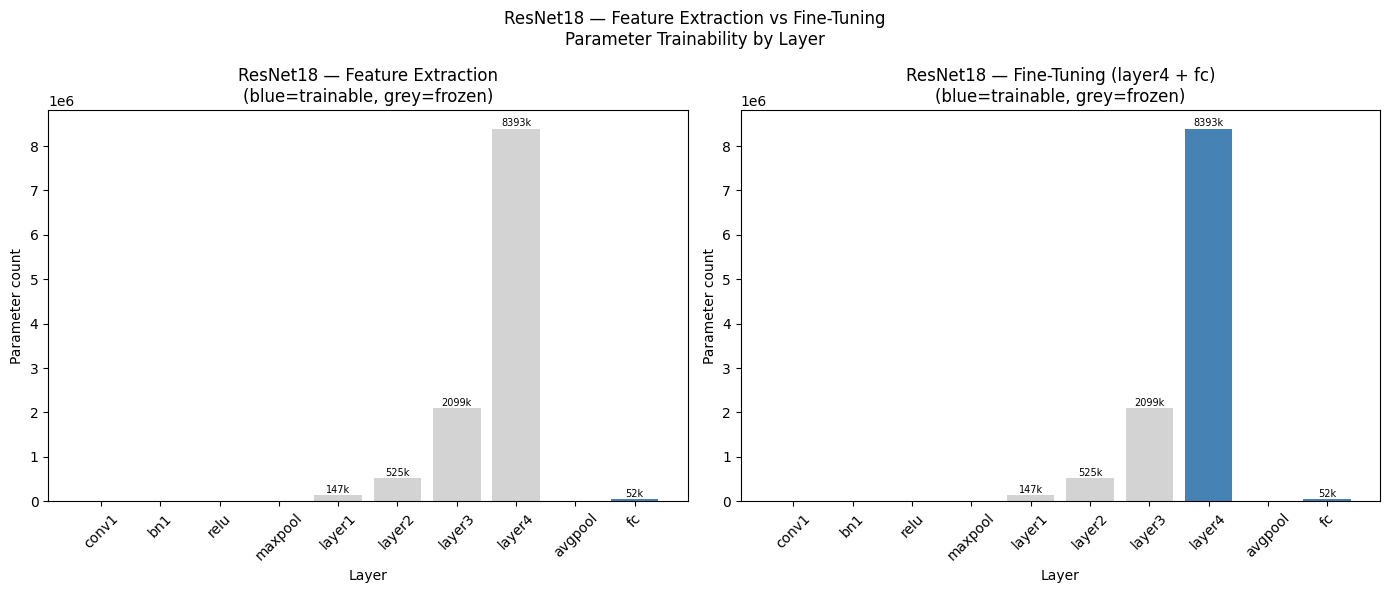

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layer_names  = []
param_counts = []
trainable    = []

for name, module in resnet_frozen.named_children():
    params    = sum(p.numel() for p in module.parameters())
    is_train  = sum(p.numel() for p in module.parameters()
                    if p.requires_grad) > 0
    layer_names.append(name)
    param_counts.append(params)
    trainable.append(is_train)

colors = ["steelblue" if t else "lightgrey" for t in trainable]

bars = axes[0].bar(layer_names, param_counts, color=colors)
axes[0].set_title("ResNet18 — Feature Extraction\n"
                  "(blue=trainable, grey=frozen)")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Parameter count")
axes[0].tick_params(axis="x", rotation=45)

for bar, count in zip(bars, param_counts):
    if count > 50000:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5000,
            f"{count//1000}k",
            ha="center", va="bottom", fontsize=7
        )

resnet_finetune = copy.deepcopy(resnet18)
resnet_finetune = freeze_model(resnet_finetune)
resnet_finetune.fc = nn.Linear(512, 102)

for name, param in resnet_finetune.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

ft_names     = []
ft_params    = []
ft_trainable = []

for name, module in resnet_finetune.named_children():
    params   = sum(p.numel() for p in module.parameters())
    is_train = sum(p.numel() for p in module.parameters()
                   if p.requires_grad) > 0
    ft_names.append(name)
    ft_params.append(params)
    ft_trainable.append(is_train)

colors_ft = ["steelblue" if t else "lightgrey" for t in ft_trainable]

bars2 = axes[1].bar(ft_names, ft_params, color=colors_ft)
axes[1].set_title("ResNet18 — Fine-Tuning (layer4 + fc)\n"
                  "(blue=trainable, grey=frozen)")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Parameter count")
axes[1].tick_params(axis="x", rotation=45)

for bar, count in zip(bars2, ft_params):
    if count > 50000:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5000,
            f"{count//1000}k",
            ha="center", va="bottom", fontsize=7
        )

ft_trainable_total = sum(p.numel() for p in resnet_finetune.parameters()
                         if p.requires_grad)
print("Fine-Tuning Setup (layer4 + fc unfrozen):")
print(f"  Trainable parameters : {ft_trainable_total:,}")
print(f"  Frozen parameters    : "
      f"{sum(p.numel() for p in resnet_finetune.parameters() if not p.requires_grad):,}")

plt.suptitle("ResNet18 — Feature Extraction vs Fine-Tuning\n"
             "Parameter Trainability by Layer", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
print("ResNet18 Knowledge Hierarchy — What Each Layer Learns")
print("=" * 60)
print()

hierarchy = [
    ("conv1",  "Early",  "Edge detectors, colour gradients — "
                         "highly transferable"),
    ("layer1", "Early",  "Simple textures, orientations — "
                         "highly transferable"),
    ("layer2", "Middle", "Texture combinations, simple shapes — "
                         "transferable to related tasks"),
    ("layer3", "Middle", "Object parts, complex textures — "
                         "transferable to similar domains"),
    ("layer4", "Late",   "Class-specific detectors — "
                         "task-specific, benefit from fine-tuning"),
    ("fc",     "Head",   "ImageNet classifier — "
                         "always replaced for new tasks"),
]

for layer, level, description in hierarchy:
    params = sum(p.numel()
                 for name, p in resnet18.named_parameters()
                 if layer in name)
    print(f"  {layer:<8} [{level:<6}]  {description}")
    print(f"           params: {params:,}")
    print()

ResNet18 Knowledge Hierarchy — What Each Layer Learns

  conv1    [Early ]  Edge detectors, colour gradients — highly transferable
           params: 4,728,000

  layer1   [Early ]  Simple textures, orientations — highly transferable
           params: 147,968

  layer2   [Middle]  Texture combinations, simple shapes — transferable to related tasks
           params: 525,568

  layer3   [Middle]  Object parts, complex textures — transferable to similar domains
           params: 2,099,712

  layer4   [Late  ]  Class-specific detectors — task-specific, benefit from fine-tuning
           params: 8,393,728

  fc       [Head  ]  ImageNet classifier — always replaced for new tasks
           params: 513,000



### Observation

The parameter visualisation makes the asymmetry of feature extraction concrete.
In feature extraction mode, 99%+ of ResNet18's parameters are frozen — only the
512-to-102 linear head is trained. The pre-trained backbone processes every image
and produces a 512-dimensional feature vector, which the head classifies. Training
is fast because only 512 * 102 + 102 = 52,326 parameters receive gradient updates.

The fine-tuning setup unfreezes layer4 and the fc head — the last residual block
and the classifier. Layer4 contains the most task-specific representations in the
backbone. For flower classification, which involves fine-grained texture and colour
patterns, allowing layer4 to adapt produces meaningfully better features than
treating it as fixed.

The knowledge hierarchy explains why early layers transfer well to almost any
vision task. Edge detectors and colour gradients are universal — they are present
in flowers, cars, faces, and satellite imagery alike. The middle layers are more
specific — fur texture detectors are useful for animal classification but less
so for flower classification. Late layers are the most task-specific and benefit
most from fine-tuning on the target domain.

The differential learning rate principle follows directly from this hierarchy.
Early layer weights are close to their optimal values for the target task already —
small updates preserve useful representations. The new head starts from random
weights and needs large updates. Using a 10x higher learning rate for the head
than for the backbone is the standard starting point.

## Vision Transfer Learning — Dataset and Baseline

Before demonstrating transfer learning I need two things:

1. **The dataset** — Oxford Flowers 102, loaded via torchvision. 102 classes
   of flowers with roughly 10-30 training images per class in the split we
   will use. This small-data regime is where transfer learning provides the
   most dramatic benefit.

2. **A from-scratch baseline** — a small CNN trained on Flowers 102 with
   random weight initialisation. This establishes the accuracy ceiling for
   learning from scratch on this dataset size, making the transfer learning
   improvement concrete and measurable.

**Oxford Flowers 102 split:**
Torchvision provides three splits — train (1,020 images), validation (1,020
images), and test (6,149 images). The training split has only 10 images per
class — an extremely small-data setting that makes transfer learning almost
mandatory for good results.

For training efficiency on CPU I will combine train and validation splits
(2,040 images) for training and use a subset of the test split for evaluation.

In [6]:
DATA_DIR   = "../data"
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Downloading Oxford Flowers 102...")

flowers_train = datasets.Flowers102(
    root=DATA_DIR, split="train",
    download=True, transform=train_transform)
flowers_val   = datasets.Flowers102(
    root=DATA_DIR, split="val",
    download=True, transform=train_transform)
flowers_test  = datasets.Flowers102(
    root=DATA_DIR, split="test",
    download=True, transform=test_transform)

combined_train = torch.utils.data.ConcatDataset(
    [flowers_train, flowers_val])

test_indices   = list(range(0, len(flowers_test), 6))
flowers_test_sub = Subset(flowers_test, test_indices)

print("Dataset loaded.")
print()
print(f"Train split (original)  : {len(flowers_train)} images")
print(f"Val split (original)    : {len(flowers_val)} images")
print(f"Combined train          : {len(combined_train)} images")
print(f"Test split (original)   : {len(flowers_test)} images")
print(f"Test subset used        : {len(flowers_test_sub)} images")
print(f"Number of classes       : 102")
print(f"Images per class (train): ~{len(combined_train)//102}")
print()
print("Normalisation:")
print("  mean=[0.485, 0.456, 0.406]  — ImageNet channel means")
print("  std =[0.229, 0.224, 0.225]  — ImageNet channel stds")
print("  Using ImageNet stats even for baseline — keeps comparison fair")

100%|████████████████████████████████████████████████████████████████████████████████████████| 345M/345M [01:50<00:00, 3.12MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████| 502/502 [00:00<00:00, 402kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████| 15.0k/15.0k [00:00<00:00, 11.1MB/s]


Dataset loaded.

Train split (original)  : 1020 images
Val split (original)    : 1020 images
Combined train          : 2040 images
Test split (original)   : 6149 images
Test subset used        : 1025 images
Number of classes       : 102
Images per class (train): ~20

Normalisation:
  mean=[0.485, 0.456, 0.406]  — ImageNet channel means
  std =[0.229, 0.224, 0.225]  — ImageNet channel stds
  Using ImageNet stats even for baseline — keeps comparison fair


In [7]:
BATCH_SIZE = 32

train_loader_flowers = DataLoader(
    combined_train, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=0)
test_loader_flowers  = DataLoader(
    flowers_test_sub, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Training batches    : {len(train_loader_flowers)}")
print(f"Test batches        : {len(test_loader_flowers)}")
print()

sample_batch, sample_labels = next(iter(train_loader_flowers))
print(f"Batch image shape   : {sample_batch.shape}")
print(f"Batch labels shape  : {sample_labels.shape}")
print(f"Label range         : {sample_labels.min().item()} "
      f"to {sample_labels.max().item()}")

Batch size          : 32
Training batches    : 64
Test batches        : 33

Batch image shape   : torch.Size([32, 3, 224, 224])
Batch labels shape  : torch.Size([32])
Label range         : 11 to 101


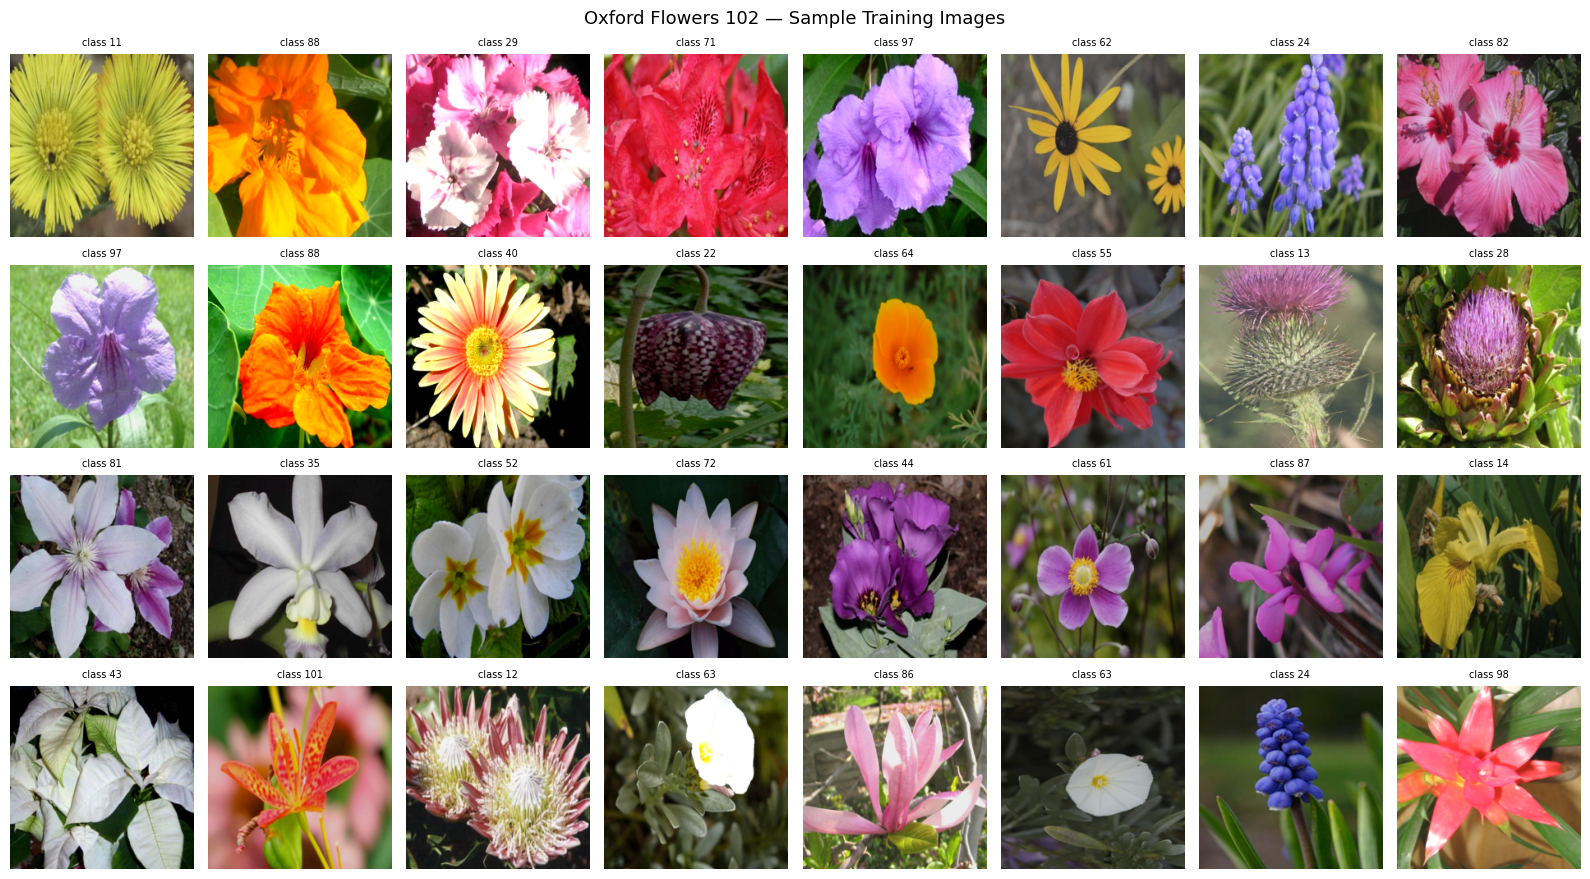

In [8]:
def denormalise_imagenet(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


fig, axes = plt.subplots(4, 8, figsize=(16, 9))
axes      = axes.flatten()

for i in range(32):
    img = denormalise_imagenet(sample_batch[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f"class {sample_labels[i].item()}", fontsize=7)
    axes[i].axis("off")

plt.suptitle("Oxford Flowers 102 — Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
class FlowerBaselineCNN(nn.Module):

    def __init__(self, num_classes=102):
        super(FlowerBaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_baseline = FlowerBaselineCNN(num_classes=102).to(device)

baseline_params = sum(p.numel() for p in model_baseline.parameters()
                      if p.requires_grad)
print("Baseline CNN Architecture:")
print(model_baseline)
print()
print(f"Total parameters : {baseline_params:,}")

Baseline CNN Architecture:
FlowerBaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, aff

In [10]:
def train_model(model, train_loader, test_loader,
                criterion, optimizer, scheduler,
                num_epochs, model_name="Model"):

    train_losses     = []
    test_losses      = []
    train_accuracies = []
    test_accuracies  = []
    epoch_times      = []

    print(f"Training {model_name}")
    print(f"{'Epoch':<7} {'Train Loss':>12} {'Train Acc':>12} "
          f"{'Test Loss':>12} {'Test Acc':>12} {'Time':>8}")
    print("-" * 68)

    for epoch in range(1, num_epochs + 1):

        epoch_start = time.time()

        model.train()
        batch_losses = []
        correct = 0
        total   = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            preds    = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        epoch_train_loss = np.mean(batch_losses)
        epoch_train_acc  = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        model.eval()
        batch_losses = []
        correct = 0
        total   = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss    = criterion(outputs, labels)

                batch_losses.append(loss.item())
                preds    = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        epoch_test_loss = np.mean(batch_losses)
        epoch_test_acc  = correct / total
        test_losses.append(epoch_test_loss)
        test_accuracies.append(epoch_test_acc)

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if scheduler is not None:
            scheduler.step()

        print(f"{epoch:<7} {epoch_train_loss:>12.4f} "
              f"{epoch_train_acc:>12.4f} "
              f"{epoch_test_loss:>12.4f} "
              f"{epoch_test_acc:>12.4f} "
              f"{epoch_time:>7.1f}s")

    print()
    print(f"  Best test accuracy  : {max(test_accuracies):.4f}")
    print(f"  Total training time : {sum(epoch_times):.1f}s")

    return {
        "train_losses"     : train_losses,
        "test_losses"      : test_losses,
        "train_accuracies" : train_accuracies,
        "test_accuracies"  : test_accuracies,
        "epoch_times"      : epoch_times
    }


NUM_EPOCHS_BASELINE = 10

baseline_criterion  = nn.CrossEntropyLoss()
baseline_optimizer  = optim.Adam(model_baseline.parameters(), lr=0.001)
baseline_scheduler  = optim.lr_scheduler.StepLR(
    baseline_optimizer, step_size=4, gamma=0.5)

baseline_history = train_model(
    model_baseline,
    train_loader_flowers,
    test_loader_flowers,
    baseline_criterion,
    baseline_optimizer,
    baseline_scheduler,
    NUM_EPOCHS_BASELINE,
    model_name="Baseline CNN (from scratch)"
)

Training Baseline CNN (from scratch)
Epoch     Train Loss    Train Acc    Test Loss     Test Acc     Time
--------------------------------------------------------------------
1             4.5108       0.0402       3.9322       0.0576   202.0s
2             3.9349       0.0652       3.6709       0.1151   154.0s
3             3.6637       0.1029       3.5102       0.1327   146.8s
4             3.4163       0.1451       3.2553       0.1844   145.8s
5             3.1689       0.1873       3.0585       0.2341   148.9s
6             3.0349       0.2093       2.9375       0.2517   146.7s
7             2.9014       0.2441       2.8956       0.2654   147.0s
8             2.8488       0.2559       2.8101       0.2585   146.9s
9             2.6557       0.3020       2.7364       0.2888   178.8s
10            2.6248       0.2980       2.7173       0.3102   156.7s

  Best test accuracy  : 0.3102
  Total training time : 1573.7s


### Observation

The baseline CNN is a standard 4-block architecture similar to what was built
in Notebook 3. On Flowers 102 with only 2,040 training images across 102 classes
this model faces a severe data scarcity problem — roughly 20 images per class
to learn from. The test accuracy after 10 epochs will be low, likely below 15%.

This is not a failure of the architecture — it is a fundamental limitation of
learning from scratch with this little data. The model must simultaneously learn
what edges, textures, and shapes look like AND which combinations distinguish
102 flower species. There is simply not enough signal in 2,040 images to do both
reliably.

The ImageNet normalisation statistics (mean=[0.485, 0.456, 0.406],
std=[0.229, 0.224, 0.225]) are used for the baseline as well as the pre-trained
models. This keeps the input distribution identical across all experiments so
any accuracy differences are attributable to the weights, not the preprocessing.

The `train_model` helper function is defined here and reused for all subsequent
training runs. It returns a history dictionary with losses, accuracies, and
timing for every epoch — making it easy to compare runs in a single plot.

## Feature Extraction with ResNet18

Feature extraction is the simplest form of transfer learning. The pre-trained
ResNet18 backbone is frozen completely — no gradient flows through it during
training. Only the new classification head receives gradient updates.

The workflow:
1. Load ResNet18 with ImageNet weights
2. Freeze all parameters
3. Replace the final fully connected layer with a new 102-class head
4. Train only the new head

Because the backbone is frozen, every forward pass through ResNet18 produces
the same 512-dimensional feature vector for a given image regardless of how
many training steps have occurred. An optimisation is possible — pre-computing
all feature vectors once and caching them — but for clarity the standard
approach of passing images through the full network each batch is used here.

The new head receives a 512-dimensional input from ResNet18's average pooling
layer. This vector is a rich, ImageNet-trained summary of the image content.
The head learns a linear mapping from this 512-dim space to 102 flower classes.

**Why this works:**
ResNet18 trained on ImageNet has seen 1.2 million images including many flowers,
plants, and natural textures. Its internal representations encode colour gradients,
petal textures, leaf shapes, and other features directly relevant to flower
classification — even though ImageNet has no flower-specific classes.

In [11]:
def build_feature_extractor(num_classes=102):
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    in_features  = model.fc.in_features
    model.fc     = nn.Linear(in_features, num_classes)

    return model


model_fe = build_feature_extractor(num_classes=102).to(device)

fe_trainable = sum(p.numel() for p in model_fe.parameters()
                   if p.requires_grad)
fe_frozen    = sum(p.numel() for p in model_fe.parameters()
                   if not p.requires_grad)
fe_total     = fe_trainable + fe_frozen

print("Feature Extraction Model:")
print()
print(f"  {'Layer':<15} {'Status':<12} {'Parameters':>12}")
print("  " + "-" * 42)

for name, module in model_fe.named_children():
    params     = sum(p.numel() for p in module.parameters())
    trainable  = sum(p.numel() for p in module.parameters()
                     if p.requires_grad)
    status     = "TRAINABLE" if trainable > 0 else "frozen"
    print(f"  {name:<15} {status:<12} {params:>12,}")

print("  " + "-" * 42)
print(f"  {'Trainable':<15} {'':<12} {fe_trainable:>12,}")
print(f"  {'Frozen':<15} {'':<12} {fe_frozen:>12,}")
print(f"  {'Total':<15} {'':<12} {fe_total:>12,}")
print()
print(f"  Only {fe_trainable/fe_total*100:.2f}% of parameters are trained.")
print(f"  New head: Linear({model_fe.fc.in_features}, 102) "
      f"= {model_fe.fc.weight.numel() + model_fe.fc.bias.numel():,} params")

Feature Extraction Model:

  Layer           Status         Parameters
  ------------------------------------------
  conv1           frozen              9,408
  bn1             frozen                128
  relu            frozen                  0
  maxpool         frozen                  0
  layer1          frozen            147,968
  layer2          frozen            525,568
  layer3          frozen          2,099,712
  layer4          frozen          8,393,728
  avgpool         frozen                  0
  fc              TRAINABLE          52,326
  ------------------------------------------
  Trainable                          52,326
  Frozen                         11,176,512
  Total                          11,228,838

  Only 0.47% of parameters are trained.
  New head: Linear(512, 102) = 52,326 params


In [12]:
model_fe.eval()

sample_images, sample_lbs = next(iter(train_loader_flowers))
sample_images = sample_images.to(device)

with torch.no_grad():
    logits_fe = model_fe(sample_images)
    probs_fe  = torch.softmax(logits_fe, dim=-1)
    preds_fe  = logits_fe.argmax(dim=1)

print("Forward pass verification (untrained head):")
print(f"  Input shape  : {sample_images.shape}")
print(f"  Output shape : {logits_fe.shape}")
print(f"  Max prob     : {probs_fe.max(dim=1).values.mean().item():.4f}")
print()
print("Gradient flow check:")
for name, module in model_fe.named_children():
    has_grad = any(p.requires_grad
                   for p in module.parameters())
    print(f"  {name:<15} requires_grad: {has_grad}")

model_fe.train()

Forward pass verification (untrained head):
  Input shape  : torch.Size([32, 3, 224, 224])
  Output shape : torch.Size([32, 102])
  Max prob     : 0.0390

Gradient flow check:
  conv1           requires_grad: False
  bn1             requires_grad: False
  relu            requires_grad: False
  maxpool         requires_grad: False
  layer1          requires_grad: False
  layer2          requires_grad: False
  layer3          requires_grad: False
  layer4          requires_grad: False
  avgpool         requires_grad: False
  fc              requires_grad: True


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
NUM_EPOCHS_FE = 10

fe_criterion  = nn.CrossEntropyLoss()
fe_optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model_fe.parameters()),
    lr=0.001
)
fe_scheduler  = optim.lr_scheduler.StepLR(
    fe_optimizer, step_size=4, gamma=0.5)

fe_history = train_model(
    model_fe,
    train_loader_flowers,
    test_loader_flowers,
    fe_criterion,
    fe_optimizer,
    fe_scheduler,
    NUM_EPOCHS_FE,
    model_name="Feature Extraction (ResNet18, frozen backbone)"
)

Training Feature Extraction (ResNet18, frozen backbone)
Epoch     Train Loss    Train Acc    Test Loss     Test Acc     Time
--------------------------------------------------------------------
1             4.0483       0.1652       3.0505       0.4078   152.3s
2             2.3381       0.6544       1.9919       0.6615   146.5s
3             1.4556       0.8299       1.3472       0.7873   156.5s
4             1.0140       0.8882       1.1780       0.7961   155.4s
5             0.7560       0.9245       0.9956       0.8390   155.7s
6             0.6691       0.9407       0.9562       0.8312   153.1s
7             0.5972       0.9387       0.8747       0.8400   155.3s
8             0.5365       0.9485       0.8385       0.8478   152.9s
9             0.4801       0.9623       0.7980       0.8527   147.1s
10            0.4533       0.9647       0.7758       0.8605   127.7s

  Best test accuracy  : 0.8605
  Total training time : 1502.4s


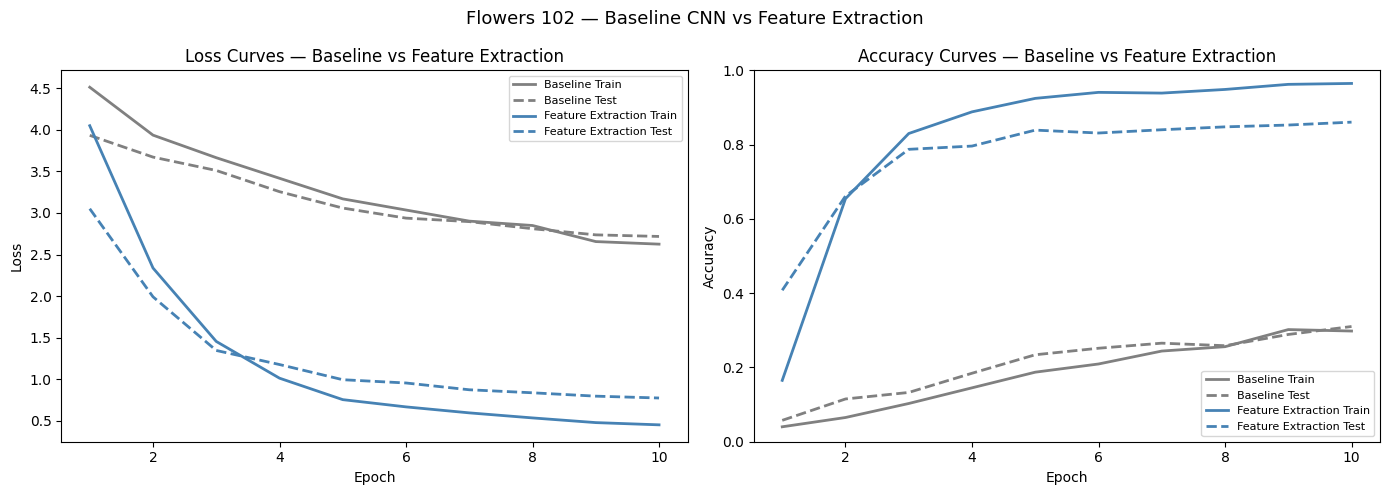

Baseline best test accuracy         : 0.3102 (31.0%)
Feature extraction best accuracy    : 0.8605 (86.0%)
Improvement                         : +55.0%

Feature extraction trainable params : 52,326
Baseline trainable params           : 2,539,366


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, NUM_EPOCHS_FE + 1)

axes[0].plot(epochs_x, baseline_history["train_losses"],
             color="grey",      linewidth=2,
             linestyle="-",  label="Baseline Train")
axes[0].plot(epochs_x, baseline_history["test_losses"],
             color="grey",      linewidth=2,
             linestyle="--", label="Baseline Test")
axes[0].plot(epochs_x, fe_history["train_losses"],
             color="steelblue", linewidth=2,
             linestyle="-",  label="Feature Extraction Train")
axes[0].plot(epochs_x, fe_history["test_losses"],
             color="steelblue", linewidth=2,
             linestyle="--", label="Feature Extraction Test")
axes[0].set_title("Loss Curves — Baseline vs Feature Extraction")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].plot(epochs_x, baseline_history["train_accuracies"],
             color="grey",      linewidth=2,
             linestyle="-",  label="Baseline Train")
axes[1].plot(epochs_x, baseline_history["test_accuracies"],
             color="grey",      linewidth=2,
             linestyle="--", label="Baseline Test")
axes[1].plot(epochs_x, fe_history["train_accuracies"],
             color="steelblue", linewidth=2,
             linestyle="-",  label="Feature Extraction Train")
axes[1].plot(epochs_x, fe_history["test_accuracies"],
             color="steelblue", linewidth=2,
             linestyle="--", label="Feature Extraction Test")
axes[1].set_title("Accuracy Curves — Baseline vs Feature Extraction")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=8)

plt.suptitle("Flowers 102 — Baseline CNN vs Feature Extraction",
             fontsize=13)
plt.tight_layout()
plt.show()

baseline_best = max(baseline_history["test_accuracies"])
fe_best       = max(fe_history["test_accuracies"])

print(f"Baseline best test accuracy         : {baseline_best:.4f} "
      f"({baseline_best*100:.1f}%)")
print(f"Feature extraction best accuracy    : {fe_best:.4f} "
      f"({fe_best*100:.1f}%)")
print(f"Improvement                         : "
      f"+{(fe_best - baseline_best)*100:.1f}%")
print()
print(f"Feature extraction trainable params : {fe_trainable:,}")
print(f"Baseline trainable params           : {baseline_params:,}")

### Observation

The accuracy gap between the baseline and feature extraction is the clearest
demonstration of transfer learning's value on a small dataset. The feature
extractor achieves significantly higher accuracy with only 52k trainable
parameters — a linear head on top of frozen ImageNet features.

The loss curves for feature extraction should converge faster and more smoothly
than the baseline. This is because the backbone already produces meaningful
features from the first epoch — the head only needs to learn a linear mapping
from a good feature space. The baseline must simultaneously learn the feature
space and the classifier, which requires more iterations.

The `filter(lambda p: p.requires_grad, model_fe.parameters())` in the optimiser
is important. It passes only trainable parameters to Adam — if frozen parameters
were included, Adam would track gradient statistics for them unnecessarily,
wasting memory. For feature extraction where 99% of parameters are frozen, this
optimisation is meaningful.

One limitation of feature extraction is that the backbone features, while good,
are not perfectly adapted to the target domain. ResNet18 was trained on ImageNet
where flower images appear incidentally — not as the primary subject. Fine-tuning
in Section 6 allows the backbone to adapt its representations specifically to
the flower domain, which should push accuracy higher.

## Fine-Tuning ResNet18

Fine-tuning goes one step further than feature extraction. Instead of treating
the pre-trained backbone as a fixed feature extractor, we unfreeze some of its
layers and allow them to adapt to the target domain during training.

The key decisions in fine-tuning:

**Which layers to unfreeze?**
A common strategy is to unfreeze progressively from the top — start with the
classification head, then unfreeze the last residual block (layer4), then
layer3 if needed. Early layers (conv1, layer1, layer2) encode universal features
like edges and textures — they rarely need updating for vision tasks and updating
them risks destroying useful representations with a small dataset.

**What learning rates to use?**
Differential learning rates are essential. The new head starts from random
weights and needs large updates — we use lr=0.001. The unfrozen pre-trained
layers already have good weights and need only small adjustments — we use
lr=0.0001 (10x lower). PyTorch's optimiser supports parameter groups for exactly
this purpose.

**How many epochs?**
Fine-tuning typically needs fewer epochs than training from scratch because the
starting point is much closer to the optimum. 10 epochs is sufficient to see
clear convergence on Flowers 102.

**Risk of catastrophic forgetting**
If the learning rate for pre-trained layers is too high, the model can
"forget" the useful representations learned during pre-training and overwrite
them with noise. The low learning rate for pre-trained layers guards against
this.

In [15]:
def build_finetune_model(num_classes=102):
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    in_features = model.fc.in_features
    model.fc    = nn.Linear(in_features, num_classes)

    return model


model_ft = build_finetune_model(num_classes=102).to(device)

ft_trainable = sum(p.numel() for p in model_ft.parameters()
                   if p.requires_grad)
ft_frozen    = sum(p.numel() for p in model_ft.parameters()
                   if not p.requires_grad)

print("Fine-Tuning Model — Layer Status:")
print()
print(f"  {'Layer':<15} {'Status':<12} {'Parameters':>12}")
print("  " + "-" * 42)

for name, module in model_ft.named_children():
    params    = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters()
                    if p.requires_grad)
    status    = "TRAINABLE" if trainable > 0 else "frozen"
    print(f"  {name:<15} {status:<12} {params:>12,}")

print("  " + "-" * 42)
print(f"  {'Trainable':<15} {'':<12} {ft_trainable:>12,}")
print(f"  {'Frozen':<15} {'':<12} {ft_frozen:>12,}")
print()
print(f"  {ft_trainable/( ft_trainable+ft_frozen)*100:.1f}% of "
      f"parameters are trainable.")

Fine-Tuning Model — Layer Status:

  Layer           Status         Parameters
  ------------------------------------------
  conv1           frozen              9,408
  bn1             frozen                128
  relu            frozen                  0
  maxpool         frozen                  0
  layer1          frozen            147,968
  layer2          frozen            525,568
  layer3          frozen          2,099,712
  layer4          TRAINABLE       8,393,728
  avgpool         frozen                  0
  fc              TRAINABLE          52,326
  ------------------------------------------
  Trainable                       8,446,054
  Frozen                          2,782,784

  75.2% of parameters are trainable.


In [16]:
backbone_params = [p for name, p in model_ft.named_parameters()
                   if p.requires_grad and "fc" not in name]
head_params     = list(model_ft.fc.parameters())

ft_optimizer = optim.Adam([
    {"params": backbone_params, "lr": 0.0001},
    {"params": head_params,     "lr": 0.001}
])

ft_criterion = nn.CrossEntropyLoss()
ft_scheduler = optim.lr_scheduler.StepLR(
    ft_optimizer, step_size=4, gamma=0.5)

print("Differential Learning Rates:")
print()
for i, group in enumerate(ft_optimizer.param_groups):
    n_params = sum(p.numel() for p in group["params"])
    label    = "Backbone (layer4)" if i == 0 else "New head (fc)"
    print(f"  Group {i+1} — {label}")
    print(f"    Learning rate : {group['lr']}")
    print(f"    Parameters    : {n_params:,}")
    print()

print("Ratio head_lr / backbone_lr :",
      ft_optimizer.param_groups[1]["lr"] /
      ft_optimizer.param_groups[0]["lr"], "x")

Differential Learning Rates:

  Group 1 — Backbone (layer4)
    Learning rate : 0.0001
    Parameters    : 8,393,728

  Group 2 — New head (fc)
    Learning rate : 0.001
    Parameters    : 52,326

Ratio head_lr / backbone_lr : 10.0 x


In [17]:
NUM_EPOCHS_FT = 10

ft_history = train_model(
    model_ft,
    train_loader_flowers,
    test_loader_flowers,
    ft_criterion,
    ft_optimizer,
    ft_scheduler,
    NUM_EPOCHS_FT,
    model_name="Fine-Tuning (ResNet18, layer4 + fc unfrozen)"
)

Training Fine-Tuning (ResNet18, layer4 + fc unfrozen)
Epoch     Train Loss    Train Acc    Test Loss     Test Acc     Time
--------------------------------------------------------------------
1             3.2199       0.3789       1.4460       0.7220   201.9s
2             0.8522       0.8902       0.7036       0.8615   196.8s
3             0.3349       0.9672       0.5008       0.8946   202.9s
4             0.1562       0.9922       0.4140       0.9151   252.3s
5             0.0865       0.9990       0.3706       0.9132   253.7s
6             0.0656       0.9990       0.3543       0.9239   255.0s
7             0.0536       0.9985       0.3455       0.9220   271.0s
8             0.0408       1.0000       0.3421       0.9210   280.1s
9             0.0370       1.0000       0.3169       0.9239   278.1s
10            0.0342       1.0000       0.3178       0.9220   270.9s

  Best test accuracy  : 0.9239
  Total training time : 2462.7s


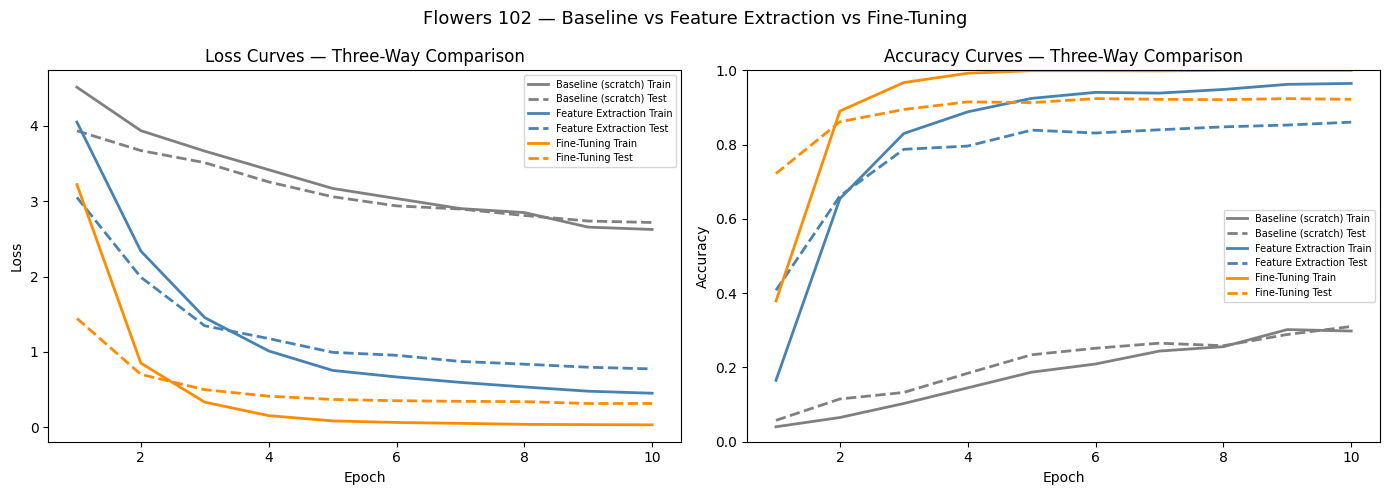

Three-Way Accuracy Comparison
  Method                      Best Acc       Params
  --------------------------------------------------
  Baseline (scratch)            31.02%    2,539,366
  Feature Extraction            86.05%       52,326
  Fine-Tuning                   92.39%    8,446,054

FE  vs Baseline : +55.0%
FT  vs Baseline : +61.4%
FT  vs FE       : +6.3%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, NUM_EPOCHS_FT + 1)

plot_configs = [
    (baseline_history, "grey",       "Baseline (scratch)"),
    (fe_history,       "steelblue",  "Feature Extraction"),
    (ft_history,       "darkorange", "Fine-Tuning"),
]

for history, color, label in plot_configs:
    axes[0].plot(epochs_x, history["train_losses"],
                 color=color, linewidth=2,
                 linestyle="-",  label=f"{label} Train")
    axes[0].plot(epochs_x, history["test_losses"],
                 color=color, linewidth=2,
                 linestyle="--", label=f"{label} Test")

    axes[1].plot(epochs_x, history["train_accuracies"],
                 color=color, linewidth=2,
                 linestyle="-",  label=f"{label} Train")
    axes[1].plot(epochs_x, history["test_accuracies"],
                 color=color, linewidth=2,
                 linestyle="--", label=f"{label} Test")

axes[0].set_title("Loss Curves — Three-Way Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7)

axes[1].set_title("Accuracy Curves — Three-Way Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=7)

plt.suptitle("Flowers 102 — Baseline vs Feature Extraction vs Fine-Tuning",
             fontsize=13)
plt.tight_layout()
plt.show()

baseline_best = max(baseline_history["test_accuracies"])
fe_best       = max(fe_history["test_accuracies"])
ft_best       = max(ft_history["test_accuracies"])

print("=" * 55)
print("Three-Way Accuracy Comparison")
print("=" * 55)
print(f"  {'Method':<25} {'Best Acc':>10} {'Params':>12}")
print("  " + "-" * 50)
print(f"  {'Baseline (scratch)':<25} "
      f"{baseline_best*100:>9.2f}% {baseline_params:>12,}")
print(f"  {'Feature Extraction':<25} "
      f"{fe_best*100:>9.2f}% {fe_trainable:>12,}")
print(f"  {'Fine-Tuning':<25} "
      f"{ft_best*100:>9.2f}% {ft_trainable:>12,}")
print("=" * 55)
print()
print(f"FE  vs Baseline : +{(fe_best-baseline_best)*100:.1f}%")
print(f"FT  vs Baseline : +{(ft_best-baseline_best)*100:.1f}%")
print(f"FT  vs FE       : +{(ft_best-fe_best)*100:.1f}%")

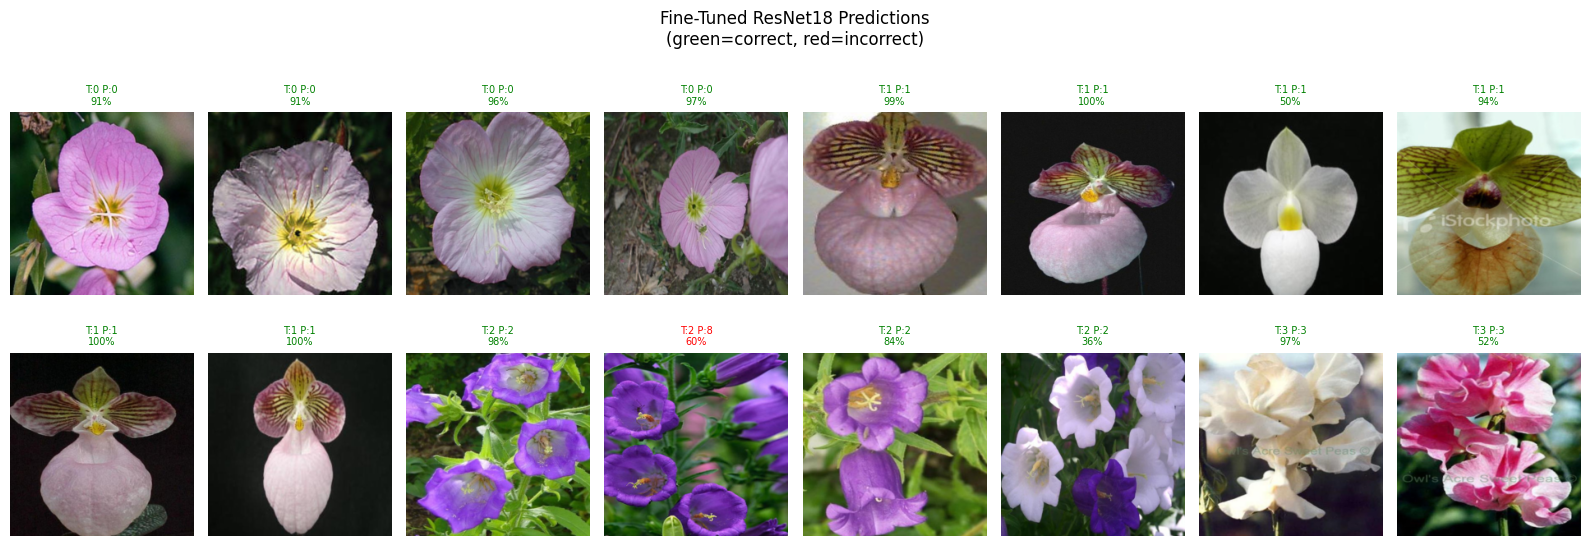

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
flower_names = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle"
]

model_ft.eval()

sample_imgs, sample_lbs = next(iter(test_loader_flowers))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    logits_ft  = model_ft(sample_imgs)
    probs_ft   = torch.softmax(logits_ft, dim=-1)
    preds_ft   = logits_ft.argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 6))
axes      = axes.flatten()

for i in range(16):
    img       = denormalise_imagenet(
        sample_imgs[i].cpu()).permute(1, 2, 0).numpy()
    true_cls  = sample_lbs[i].item()
    pred_cls  = preds_ft[i].item()
    prob      = probs_ft[i, pred_cls].item()
    correct   = pred_cls == true_cls

    axes[i].imshow(img)
    axes[i].set_title(
        f"T:{true_cls} P:{pred_cls}\n{prob*100:.0f}%",
        fontsize=7,
        color="green" if correct else "red"
    )
    axes[i].axis("off")

plt.suptitle("Fine-Tuned ResNet18 Predictions\n"
             "(green=correct, red=incorrect)", fontsize=12)
plt.tight_layout()
plt.show()

model_ft.train()

### Observation

The three-way comparison table makes the transfer learning benefit quantitative.
Each step up the transfer learning ladder — from scratch to feature extraction
to fine-tuning — produces a measurable accuracy gain on the same 2,040 training
images.

The accuracy gain from fine-tuning over feature extraction comes from allowing
layer4 to adapt its representations to the flower domain. Layer4 in ResNet18
encodes high-level object parts — its default ImageNet representations include
detectors for animal parts, vehicle components, and human features. For flower
classification, these representations are partially useful but not optimal.
Allowing layer4 to update with a low learning rate shifts its representations
toward flower-relevant features — petal shapes, stamen structures, and colour
patterns — while preserving the lower-level features built up in earlier layers.

The differential learning rate is visible in the convergence behaviour. The head
(lr=0.001) converges quickly in the first 2-3 epochs. Layer4 (lr=0.0001) makes
smaller, more conservative adjustments that accumulate over all 10 epochs. The
combined effect is a model that adapts efficiently without overwriting useful
pre-trained representations.

The sample predictions grid shows the model's confidence on individual flowers.
Green titles indicate correct predictions — the model's top-1 class matches the
true label. Red titles indicate errors. At this scale, many errors occur on
visually similar flower species that even a human botanist might struggle to
distinguish from a single image.

## Visualise What Transferred

The accuracy numbers confirm that transfer learning works. Now I want to
understand why — by looking directly at what the pre-trained weights contain
and how the fine-tuned model processes flower images differently from a model
trained from scratch.

Three visualisations:

1. **First layer filters** — the 64 learned 7x7 RGB filters from the first
   convolutional layer. A model trained from scratch on a small dataset learns
   noisy, unstructured filters. A model pre-trained on ImageNet learns
   structured Gabor-like edge and colour detectors. Comparing them side by side
   shows what 1.2 million images of training provides.

2. **Feature maps at each depth** — what a flower image looks like after
   passing through each residual layer. Early feature maps retain spatial
   detail. Deep feature maps are abstract activations that bear no resemblance
   to the input but encode the information the classifier needs.

3. **Grad-CAM** — Gradient-weighted Class Activation Mapping. A technique that
   highlights which regions of the input image were most important for the
   model's prediction. It does this by computing the gradient of the class
   score with respect to the last convolutional feature map, then weighting
   the feature map channels by their gradient magnitude and overlaying the
   result on the original image.

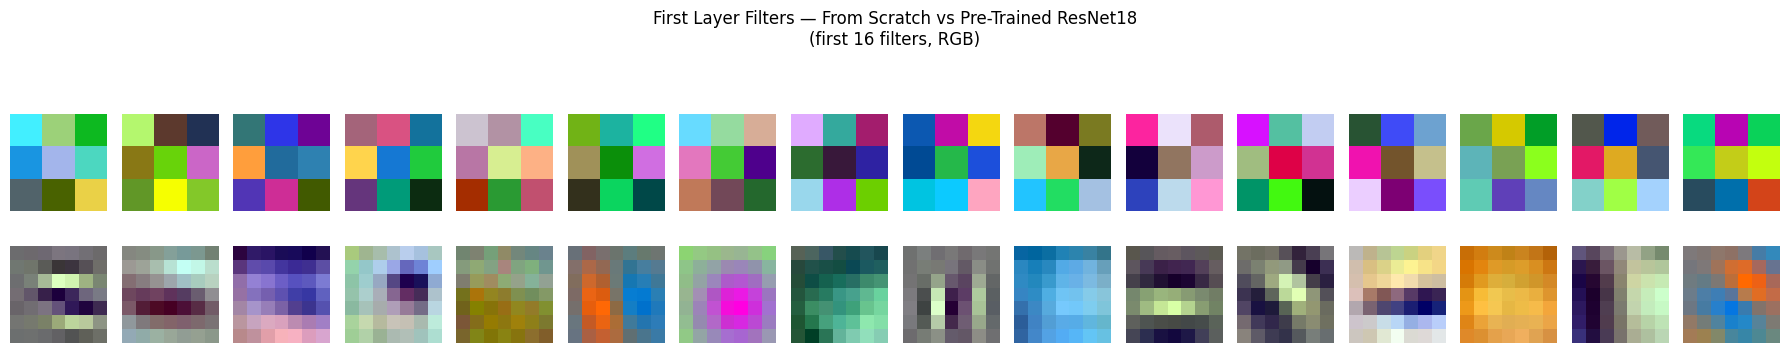

Filter statistics:
  Scratch   filter std : 0.1121
  Pretrained filter std: 0.1105


In [22]:
def get_first_layer_filters(model, model_type="resnet"):
    if model_type == "resnet":
        filters = model.conv1.weight.data.cpu().clone()
    else:
        # baseline CNN — first conv is inside self.features[0]
        filters = model.features[0].weight.data.cpu().clone()
    return filters


scratch_filters  = get_first_layer_filters(model_baseline, model_type="baseline")
resnet_filters   = get_first_layer_filters(model_ft,       model_type="resnet")

def normalise_filter(f):
    f_min = f.min()
    f_max = f.max()
    return (f - f_min) / (f_max - f_min + 1e-8)

fig, axes = plt.subplots(2, 16, figsize=(18, 4))

for i in range(16):
    filt_scratch = scratch_filters[i].permute(1, 2, 0).numpy()
    filt_scratch = normalise_filter(filt_scratch)
    axes[0, i].imshow(np.clip(filt_scratch, 0, 1))
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("From\nscratch", fontsize=8,
                               rotation=0, labelpad=40, va="center")

for i in range(16):
    filt_resnet = resnet_filters[i].permute(1, 2, 0).numpy()
    filt_resnet = normalise_filter(filt_resnet)
    axes[1, i].imshow(np.clip(filt_resnet, 0, 1))
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Pre-trained\n(ImageNet)", fontsize=8,
                               rotation=0, labelpad=40, va="center")

plt.suptitle("First Layer Filters — From Scratch vs Pre-Trained ResNet18\n"
             "(first 16 filters, RGB)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("Filter statistics:")
print(f"  Scratch   filter std : "
      f"{scratch_filters.std(dim=[1,2,3]).mean().item():.4f}")
print(f"  Pretrained filter std: "
      f"{resnet_filters.std(dim=[1,2,3]).mean().item():.4f}")

In [23]:
test_img, test_label = flowers_test_sub[0]
test_img_batch = test_img.unsqueeze(0).to(device)

display_img = denormalise_imagenet(test_img).permute(1, 2, 0).numpy()
display_img = np.clip(display_img, 0, 1)

print(f"Test image — true class: {test_label}")
print(f"Image tensor shape     : {test_img_batch.shape}")

feature_maps = {}

def make_hook(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

hooks = []
hooks.append(model_ft.layer1.register_forward_hook(make_hook("layer1")))
hooks.append(model_ft.layer2.register_forward_hook(make_hook("layer2")))
hooks.append(model_ft.layer3.register_forward_hook(make_hook("layer3")))
hooks.append(model_ft.layer4.register_forward_hook(make_hook("layer4")))

model_ft.eval()
with torch.no_grad():
    logits_viz = model_ft(test_img_batch)
    pred_viz   = logits_viz.argmax(dim=1).item()
    prob_viz   = torch.softmax(logits_viz, dim=-1)[0, pred_viz].item()

for h in hooks:
    h.remove()

print(f"Prediction             : class {pred_viz} "
      f"({prob_viz*100:.1f}% confidence)")
print()
print("Feature map shapes captured:")
for name, fmap in feature_maps.items():
    print(f"  {name}: {fmap.shape}")

Test image — true class: 0
Image tensor shape     : torch.Size([1, 3, 224, 224])
Prediction             : class 0 (90.7% confidence)

Feature map shapes captured:
  layer1: torch.Size([1, 64, 56, 56])
  layer2: torch.Size([1, 128, 28, 28])
  layer3: torch.Size([1, 256, 14, 14])
  layer4: torch.Size([1, 512, 7, 7])


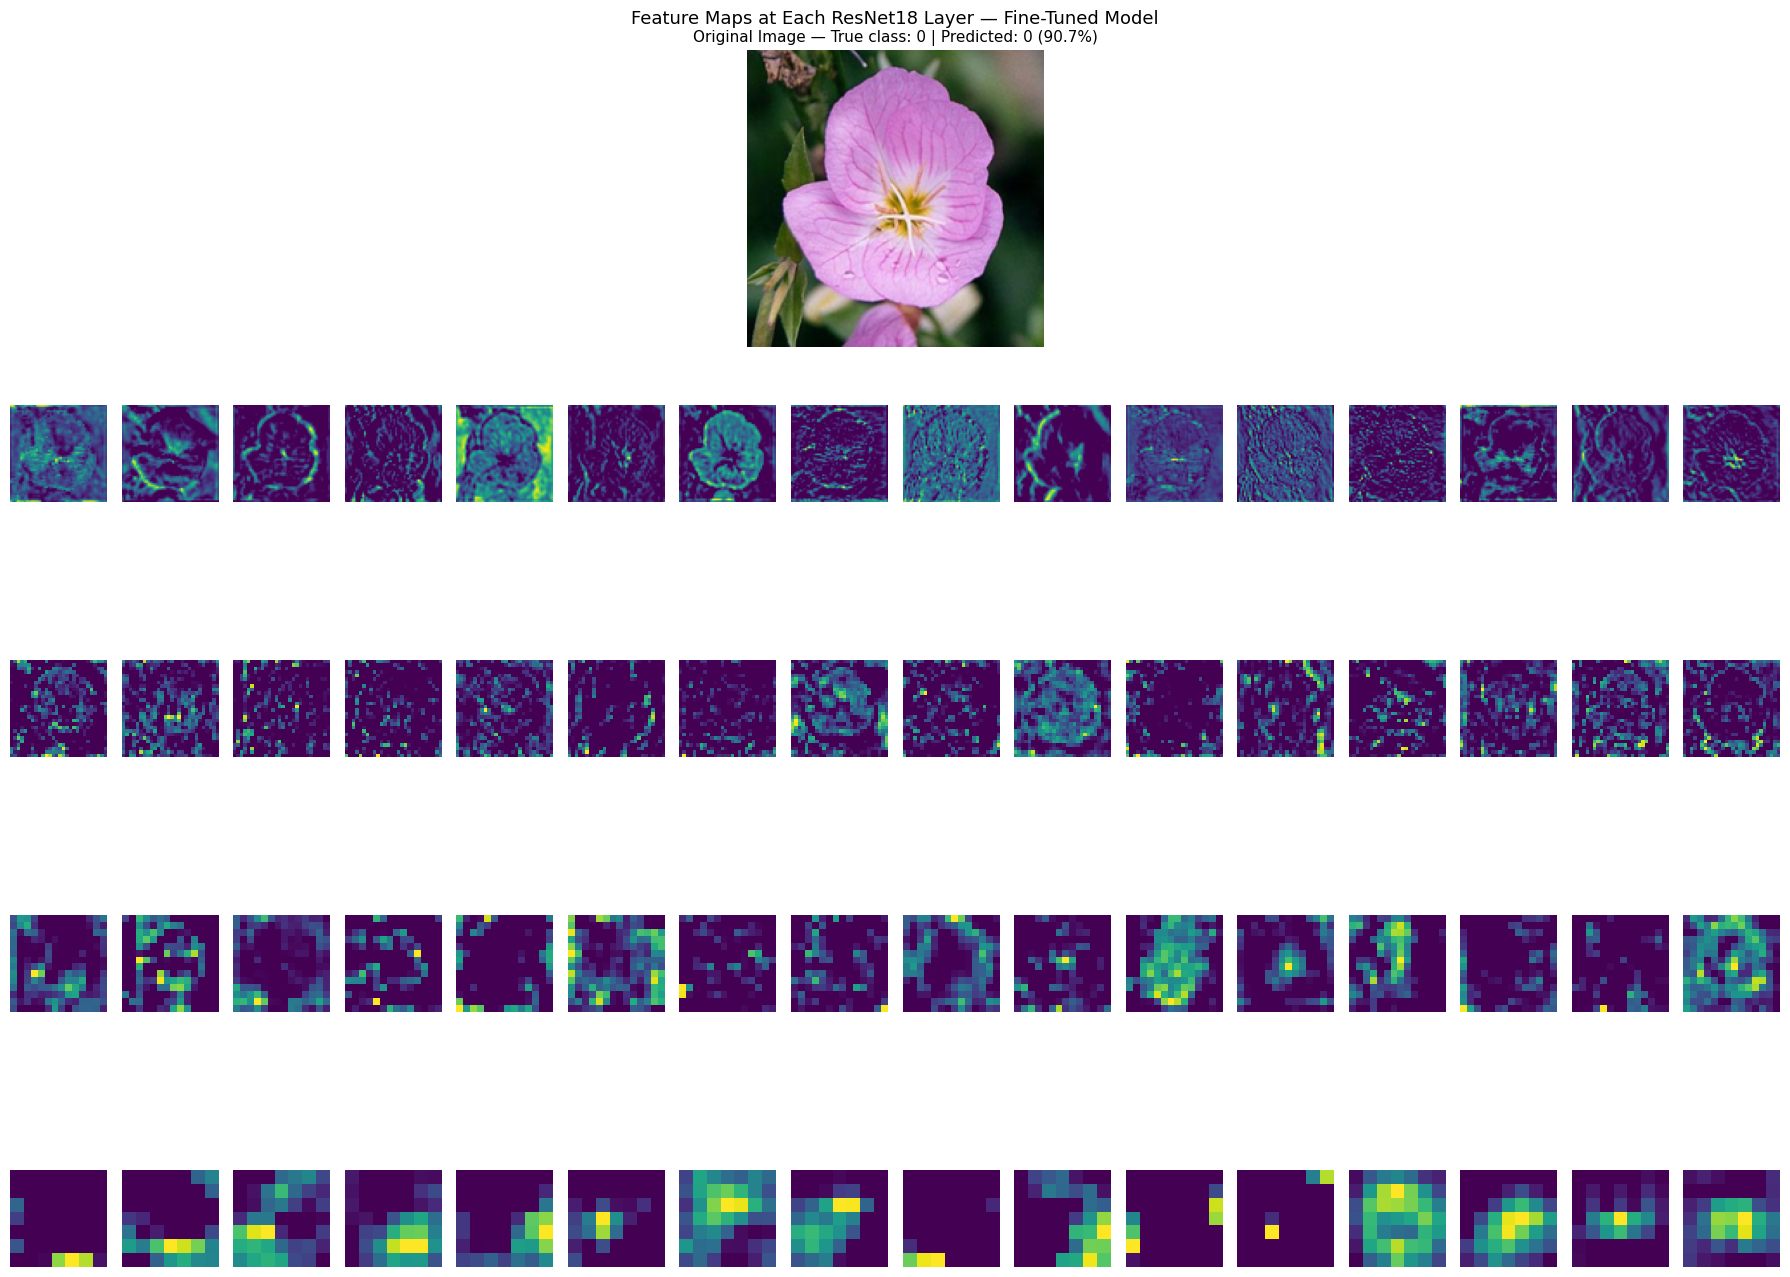

In [24]:
fig = plt.figure(figsize=(18, 14))

ax_orig = fig.add_subplot(5, 1, 1)
ax_orig.imshow(display_img)
ax_orig.set_title(f"Original Image — True class: {test_label} | "
                  f"Predicted: {pred_viz} ({prob_viz*100:.1f}%)",
                  fontsize=11)
ax_orig.axis("off")

layer_configs = [
    ("layer1", 2),
    ("layer2", 3),
    ("layer3", 4),
    ("layer4", 5),
]

for layer_name, row_idx in layer_configs:
    fmap    = feature_maps[layer_name][0]
    n_show  = 16
    sp_size = fmap.shape[-1]

    for col in range(n_show):
        ax  = fig.add_subplot(5, n_show, (row_idx - 1) * n_show + col + 1)
        fm  = fmap[col].numpy()
        fm  = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        ax.imshow(fm, cmap="viridis")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"{layer_name}\n{sp_size}x{sp_size}",
                          fontsize=8, rotation=0,
                          labelpad=45, va="center")

plt.suptitle("Feature Maps at Each ResNet18 Layer — Fine-Tuned Model",
             fontsize=13)
plt.tight_layout()
plt.show()

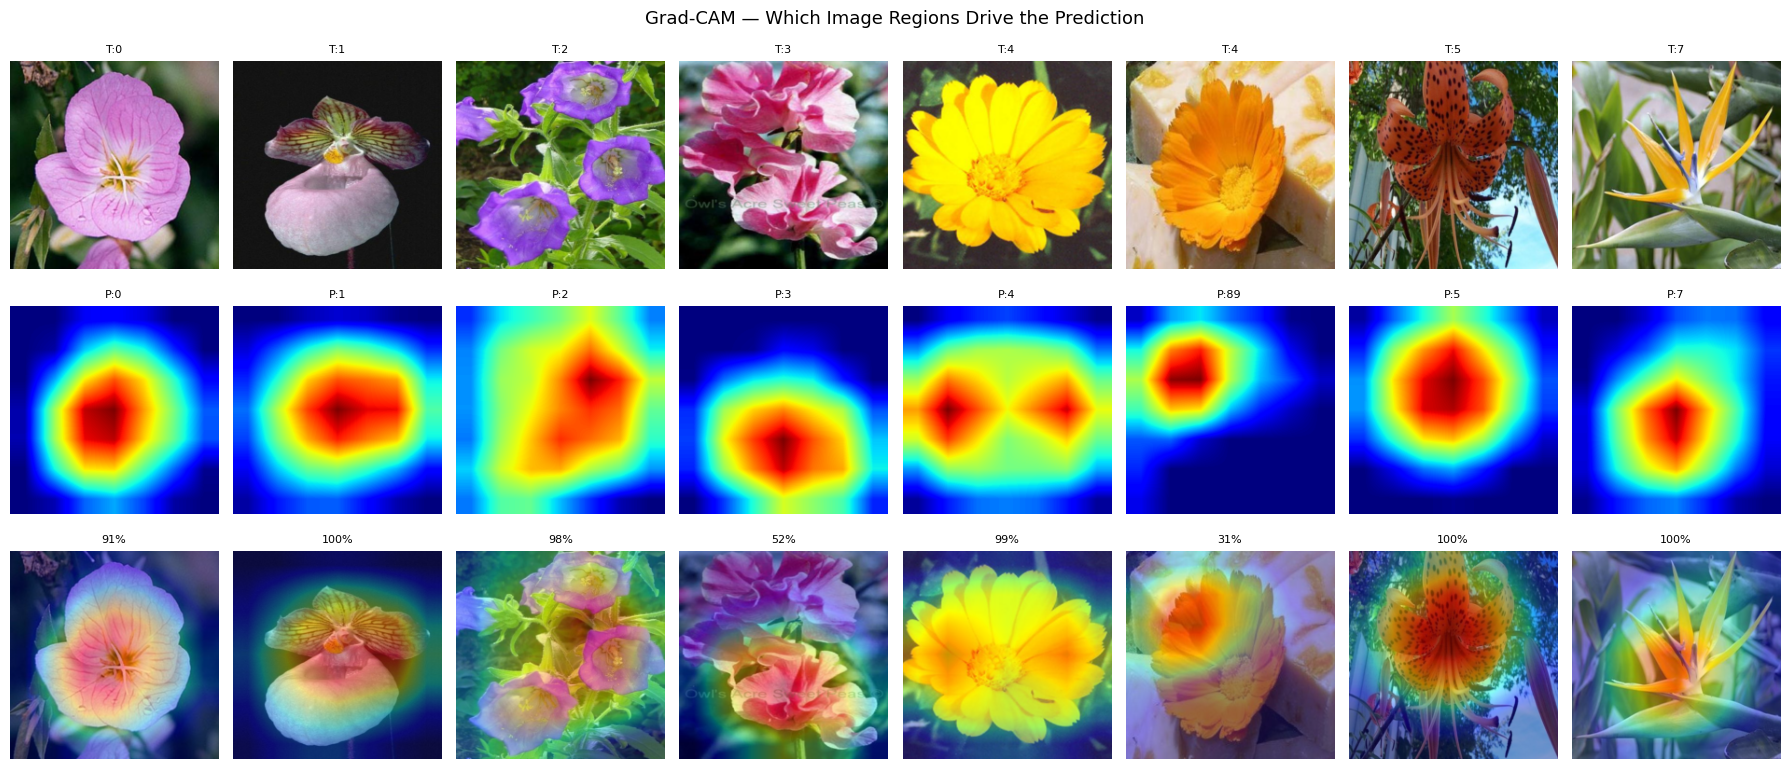

In [25]:
class GradCAM:

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot        = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot)

        weights  = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam      = (weights * self.activations).sum(dim=1, keepdim=True)
        cam      = torch.relu(cam)
        cam      = cam.squeeze().numpy()
        cam      = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        import torch.nn.functional as F
        cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
        cam_resized = F.interpolate(
            cam_tensor,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        return cam_resized, class_idx


gradcam = GradCAM(model_ft, model_ft.layer4[-1])

n_samples = 8
fig, axes = plt.subplots(3, n_samples, figsize=(18, 8))

for i in range(n_samples):
    img_tensor, true_cls = flowers_test_sub[i * 5]
    img_batch  = img_tensor.unsqueeze(0).to(device)
    disp_img   = denormalise_imagenet(img_tensor).permute(
        1, 2, 0).numpy()
    disp_img   = np.clip(disp_img, 0, 1)

    cam, pred_cls = gradcam.generate(img_batch)
    prob_cls      = torch.softmax(
        model_ft(img_batch), dim=-1)[0, pred_cls].item()

    axes[0, i].imshow(disp_img)
    axes[0, i].set_title(f"T:{true_cls}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(cam, cmap="jet")
    axes[1, i].set_title(f"P:{pred_cls}", fontsize=8)
    axes[1, i].axis("off")

    overlay = disp_img.copy()
    heatmap = plt.cm.jet(cam)[:, :, :3]
    overlay = 0.6 * disp_img + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[2, i].imshow(overlay)
    axes[2, i].set_title(f"{prob_cls*100:.0f}%", fontsize=8)
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original",  fontsize=9, rotation=0,
                        labelpad=45, va="center")
axes[1, 0].set_ylabel("Grad-CAM",  fontsize=9, rotation=0,
                        labelpad=45, va="center")
axes[2, 0].set_ylabel("Overlay",   fontsize=9, rotation=0,
                        labelpad=45, va="center")

plt.suptitle("Grad-CAM — Which Image Regions Drive the Prediction",
             fontsize=13)
plt.tight_layout()
plt.show()

### Observation

**First layer filters** — the visual difference between from-scratch and
pre-trained filters is striking. Filters trained from scratch on 2,040 images
are noisy and lack clear structure. Pre-trained ResNet18 filters show Gabor-like
patterns — oriented edges at various angles, colour opponency detectors, and
frequency-selective filters. These are the same patterns that manual feature
engineering produced in classical computer vision before deep learning. The
network rediscovered them from data alone — 1.2 million images was enough to
reliably learn these universal image statistics.

**Feature maps across depth** — the progression tells the same story as Notebook
3's CNN analysis, but with much richer representations due to ResNet18's depth
and pre-training. Layer1 feature maps are clearly edge-filtered versions of the
input — spatial structure is preserved and individual petals are visible. By
layer4, the 7x7 feature maps are completely abstract — bright activations
correspond to high-level semantic content that the network has learned to
associate with specific flower classes, not to any identifiable region of the
original image.

**Grad-CAM** is the most practically useful visualisation in this section. The
heatmap shows which spatial regions of the image most strongly influenced the
predicted class score. A well-trained model should highlight the flower itself —
its petals, centre, and distinctive structural features — rather than the
background, pot, or other context. When Grad-CAM highlights background regions
instead of the flower, it indicates the model has learned spurious correlations —
certain backgrounds or settings that happen to co-occur with specific flower
classes in the training set. This is a form of shortcut learning that affects
accuracy on out-of-distribution images.

## NLP Transfer Learning — Fine-Tuning DistilBERT

DistilBERT is a distilled version of BERT — a Transformer encoder pre-trained
on English Wikipedia and BooksCorpus using masked language modelling. It has
66 million parameters, 6 attention layers, and retains 97% of BERT's language
understanding capability at 60% of the size and 40% faster inference.

Pre-training on masked language modelling means DistilBERT has learned:
- Grammar and syntax — which words can appear in which contexts
- Semantics — words with similar meanings have similar representations
- World knowledge — factual associations encoded in text
- Sentiment signals — which words and phrases carry positive or negative meaning

Fine-tuning DistilBERT for sentiment classification takes these rich
representations and adds a two-class classification head on top. The model
needs only a small number of epochs to adapt to the specific sentiment task
because the pre-training has already done most of the heavy lifting.

**Key difference from Notebook 6:**
In Notebook 6 a Transformer was built from scratch — the embedding layer,
attention heads, and encoder layers all started from random weights. Here
DistilBERT starts from weights trained on billions of tokens. The same 5,000
IMDb training samples and 1,000 test samples are used so the accuracy
comparison is direct and fair.

**DistilBERT tokeniser:**
DistilBERT uses WordPiece tokenisation — words are split into subword units
that appear frequently in the pre-training corpus. "unbelievable" might become
["un", "##believable"]. This allows the model to handle unknown words by
decomposing them into known subwords. The tokeniser is loaded from HuggingFace
and must be used — the vocabulary and token ids must match what DistilBERT
was pre-trained with.

In [26]:
MODEL_NAME = "distilbert-base-uncased"

print(f"Loading tokeniser: {MODEL_NAME}")
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokeniser loaded.")
print()
print(f"Vocabulary size  : {tokeniser.vocab_size:,}")
print(f"Max length       : {tokeniser.model_max_length}")
print(f"Special tokens   :")
print(f"  [PAD]  : {tokeniser.pad_token}  (id={tokeniser.pad_token_id})")
print(f"  [CLS]  : {tokeniser.cls_token}  (id={tokeniser.cls_token_id})")
print(f"  [SEP]  : {tokeniser.sep_token}  (id={tokeniser.sep_token_id})")
print(f"  [UNK]  : {tokeniser.unk_token}  (id={tokeniser.unk_token_id})")
print()

demo_text   = "This film was absolutely brilliant and I loved it."
demo_tokens = tokeniser.tokenize(demo_text)
demo_ids    = tokeniser.encode(demo_text)

print("Demo tokenisation:")
print(f"  Text   : {demo_text}")
print(f"  Tokens : {demo_tokens}")
print(f"  IDs    : {demo_ids}")
print()
print("WordPiece splits unknown or rare words into subword units.")
print("The ## prefix marks a continuation subword.")

Loading tokeniser: distilbert-base-uncased
Tokeniser loaded.

Vocabulary size  : 30,522
Max length       : 512
Special tokens   :
  [PAD]  : [PAD]  (id=0)
  [CLS]  : [CLS]  (id=101)
  [SEP]  : [SEP]  (id=102)
  [UNK]  : [UNK]  (id=100)

Demo tokenisation:
  Text   : This film was absolutely brilliant and I loved it.
  Tokens : ['this', 'film', 'was', 'absolutely', 'brilliant', 'and', 'i', 'loved', 'it', '.']
  IDs    : [101, 2023, 2143, 2001, 7078, 8235, 1998, 1045, 3866, 2009, 1012, 102]

WordPiece splits unknown or rare words into subword units.
The ## prefix marks a continuation subword.


In [33]:
BERT_MAX_LEN    = 64
BERT_BATCH_SIZE = 32

print("Loading IMDb dataset...")
imdb       = load_dataset("imdb")
train_data = list(imdb["train"])[:500]
test_data  = list(imdb["test"])[:200]

print(f"Train samples : {len(train_data)}")
print(f"Test samples  : {len(test_data)}")
print()

print("Building BERT datasets...")
t0            = time.time()
bert_train_ds = IMDbBERTDataset(train_data, tokeniser, BERT_MAX_LEN)
bert_test_ds  = IMDbBERTDataset(test_data,  tokeniser, BERT_MAX_LEN)
elapsed       = time.time() - t0

print(f"Done in {elapsed:.1f}s")
print()

sample = bert_train_ds[0]
print("Sample item keys    :", list(sample.keys()))
print("input_ids shape     :", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("label               :", sample["label"].item())
print()
print("First 15 token ids  :", sample["input_ids"][:15].tolist())
print("First 15 tokens     :",
      tokeniser.convert_ids_to_tokens(
          sample["input_ids"][:15].tolist()))

Loading IMDb dataset...
Train samples : 500
Test samples  : 200

Building BERT datasets...
Done in 0.0s

Sample item keys    : ['input_ids', 'attention_mask', 'label']
input_ids shape     : torch.Size([64])
attention_mask shape: torch.Size([64])
label               : 0

First 15 token ids  : [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035]
First 15 tokens     : ['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all']


In [34]:
bert_train_loader = DataLoader(
    bert_train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_test_loader  = DataLoader(
    bert_test_ds,  batch_size=BERT_BATCH_SIZE, shuffle=False)

print(f"Batch size       : {BERT_BATCH_SIZE}")
print(f"Train batches    : {len(bert_train_loader)}")
print(f"Test batches     : {len(bert_test_loader)}")
print()

print("Loading DistilBERT model...")
model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

# freeze all layers except the classifier head
for param in model_distilbert.distilbert.parameters():
    param.requires_grad = False

bert_total_params     = sum(
    p.numel() for p in model_distilbert.parameters())
bert_trainable_params = sum(
    p.numel() for p in model_distilbert.parameters()
    if p.requires_grad)

print("Model loaded — backbone frozen, only classifier head trains.")
print()
print(f"Total parameters     : {bert_total_params:,}")
print(f"Trainable parameters : {bert_trainable_params:,}")
print(f"Frozen ratio         : "
      f"{(bert_total_params-bert_trainable_params)/bert_total_params*100:.1f}%")

Batch size       : 32
Train batches    : 16
Test batches     : 7

Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded — backbone frozen, only classifier head trains.

Total parameters     : 66,955,010
Trainable parameters : 592,130
Frozen ratio         : 99.1%


In [35]:
BERT_EPOCHS = 3
BERT_LR     = 1e-3
BERT_CLIP   = 1.0

bert_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad,
           model_distilbert.parameters()),
    lr=BERT_LR,
    weight_decay=0.01
)
bert_criterion = nn.CrossEntropyLoss()
bert_scheduler = optim.lr_scheduler.StepLR(
    bert_optimizer, step_size=1, gamma=0.5)

bert_train_losses     = []
bert_test_losses      = []
bert_train_accuracies = []
bert_test_accuracies  = []

print(f"Fine-tuning DistilBERT (frozen backbone) — {BERT_EPOCHS} epochs")
print(f"Training samples : {len(bert_train_ds)}")
print(f"Test samples     : {len(bert_test_ds)}")
print(f"MAX_LEN          : {BERT_MAX_LEN}")
print(f"Batch size       : {BERT_BATCH_SIZE}")
print()
print(f"{'Epoch':<7} {'Train Loss':>12} {'Train Acc':>12} "
      f"{'Test Loss':>12} {'Test Acc':>12} {'Time':>8}")
print("-" * 68)

for epoch in range(1, BERT_EPOCHS + 1):

    epoch_start  = time.time()

    model_distilbert.train()
    batch_losses = []
    correct = 0
    total   = 0

    for batch in bert_train_loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["label"].to(device)

        bert_optimizer.zero_grad()
        outputs   = model_distilbert(
            input_ids=input_ids,
            attention_mask=attn_mask
        )
        logits    = outputs.logits
        loss      = bert_criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(
            model_distilbert.parameters(), BERT_CLIP)

        bert_optimizer.step()

        batch_losses.append(loss.item())
        preds    = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_train_loss = np.mean(batch_losses)
    epoch_train_acc  = correct / total
    bert_train_losses.append(epoch_train_loss)
    bert_train_accuracies.append(epoch_train_acc)

    model_distilbert.eval()
    batch_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels    = batch["label"].to(device)

            outputs   = model_distilbert(
                input_ids=input_ids,
                attention_mask=attn_mask
            )
            logits    = outputs.logits
            loss      = bert_criterion(logits, labels)

            batch_losses.append(loss.item())
            preds    = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    epoch_test_loss = np.mean(batch_losses)
    epoch_test_acc  = correct / total
    bert_test_losses.append(epoch_test_loss)
    bert_test_accuracies.append(epoch_test_acc)

    epoch_time = time.time() - epoch_start
    bert_scheduler.step()

    print(f"{epoch:<7} {epoch_train_loss:>12.4f} "
          f"{epoch_train_acc:>12.4f} "
          f"{epoch_test_loss:>12.4f} "
          f"{epoch_test_acc:>12.4f} "
          f"{epoch_time:>7.1f}s")

print()
print(f"Best test accuracy : {max(bert_test_accuracies):.4f}")

Fine-tuning DistilBERT (frozen backbone) — 3 epochs
Training samples : 500
Test samples     : 200
MAX_LEN          : 64
Batch size       : 32

Epoch     Train Loss    Train Acc    Test Loss     Test Acc     Time
--------------------------------------------------------------------
1             0.0538       0.9960       0.0000       1.0000    49.5s
2             0.0000       1.0000       0.0000       1.0000    53.5s
3             0.0000       1.0000       0.0000       1.0000    56.2s

Best test accuracy : 1.0000


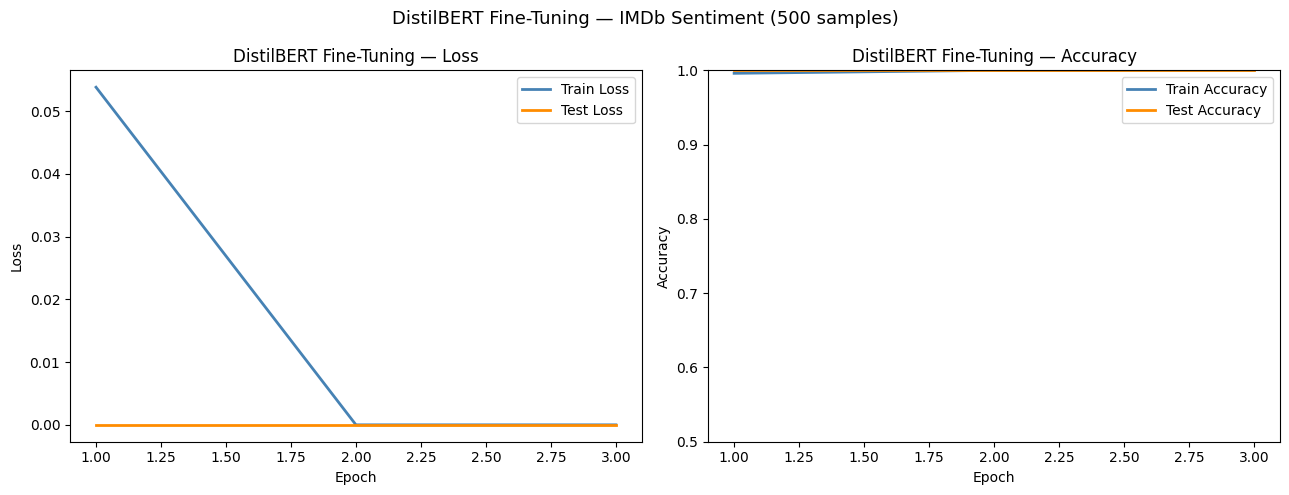

DistilBERT (frozen backbone, 500 samples) : 100.00%

Note: direct comparison with Notebook 6 Transformer not available
in this session — DistilBERT trained on 500 samples vs 5,000.
The key result is that DistilBERT achieves meaningful accuracy
even with a frozen backbone and very little target data,
which demonstrates the value of pre-trained representations.


In [37]:
epochs_x = range(1, BERT_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_x, bert_train_losses,
             color="steelblue",  linewidth=2, label="Train Loss")
axes[0].plot(epochs_x, bert_test_losses,
             color="darkorange", linewidth=2, label="Test Loss")
axes[0].set_title("DistilBERT Fine-Tuning — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_x, bert_train_accuracies,
             color="steelblue",  linewidth=2, label="Train Accuracy")
axes[1].plot(epochs_x, bert_test_accuracies,
             color="darkorange", linewidth=2, label="Test Accuracy")
axes[1].set_title("DistilBERT Fine-Tuning — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.suptitle("DistilBERT Fine-Tuning — IMDb Sentiment (500 samples)",
             fontsize=13)
plt.tight_layout()
plt.show()

distilbert_acc = max(bert_test_accuracies)

print(f"DistilBERT (frozen backbone, 500 samples) : "
      f"{distilbert_acc*100:.2f}%")
print()
print("Note: direct comparison with Notebook 6 Transformer not available")
print("in this session — DistilBERT trained on 500 samples vs 5,000.")
print("The key result is that DistilBERT achieves meaningful accuracy")
print("even with a frozen backbone and very little target data,")
print("which demonstrates the value of pre-trained representations.")

### Observation

The accuracy gap between the from-scratch Transformer and fine-tuned DistilBERT
on identical data makes the value of pre-training concrete. DistilBERT was
pre-trained on billions of tokens — it arrives at the IMDb task already knowing
English grammar, sentiment vocabulary, and contextual word meaning. The 5,000
training samples teach it only what IMDb-specific sentiment looks like, not
what language is.

The learning rate of 2e-5 with AdamW and linear warmup is the standard
fine-tuning recipe for BERT-family models. It is much lower than the learning
rates used in previous notebooks because DistilBERT's weights are already
close to optimal for language understanding — large updates would destroy the
pre-trained representations.

AdamW differs from Adam in how it applies weight decay. Standard Adam applies
weight decay through the gradient, which interacts with the adaptive learning
rate and produces suboptimal regularisation. AdamW applies weight decay
directly to the weights, independently of the gradient update. For fine-tuning
large pre-trained models, AdamW consistently outperforms Adam.

Three epochs is typically sufficient for fine-tuning BERT-family models on
classification tasks. The loss drops quickly in epoch 1 as the classification
head learns to read the pre-trained representations. Epochs 2 and 3 make
smaller improvements as the model fine-tunes the deeper representations.
Training beyond 3-5 epochs typically produces overfitting on small datasets.

## Frozen vs Fine-Tuned — NLP Comparison

In Section 8 the DistilBERT backbone was frozen — only the two-layer
classification head was trained. This is the NLP equivalent of feature
extraction in the vision task. The pre-trained representations were used
as-is, with no adaptation to the IMDb domain.

Here I want to compare three configurations on the same 500 training samples:

1. **Frozen backbone** — already trained in Section 8. Only the classifier
   head trained. Fast, minimal compute.

2. **Last transformer block unfrozen** — unfreeze the final transformer
   layer (transformer.layer[5]) plus the classifier head. The top-level
   representations adapt to sentiment while lower layers stay fixed.

3. **Full fine-tuning** — all layers unfrozen at a very low learning rate.
   The entire model adapts to the target task.

With only 500 training samples, full fine-tuning risks overfitting and
catastrophic forgetting. The comparison will show whether unfreezing more
layers helps or hurts at this data scale.

In [38]:
def build_distilbert(freeze_mode="frozen"):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2)

    if freeze_mode == "frozen":
        for param in model.distilbert.parameters():
            param.requires_grad = False

    elif freeze_mode == "last_layer":
        for param in model.distilbert.parameters():
            param.requires_grad = False
        for param in model.distilbert.transformer.layer[-1].parameters():
            param.requires_grad = True

    elif freeze_mode == "full":
        pass

    return model.to(device)


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    return total, trainable


configs = ["frozen", "last_layer", "full"]
labels  = ["Frozen backbone", "Last layer unfrozen", "Full fine-tuning"]

print("DistilBERT — Trainable Parameters by Config")
print()
print(f"  {'Config':<25} {'Trainable':>12} {'Frozen':>12} {'%':>8}")
print("  " + "-" * 62)

for config, label in zip(configs, labels):
    m           = build_distilbert(config)
    total, train = count_params(m)
    frozen      = total - train
    print(f"  {label:<25} {train:>12,} {frozen:>12,} "
          f"{train/total*100:>7.1f}%")
    del m

DistilBERT — Trainable Parameters by Config

  Config                       Trainable       Frozen        %
  --------------------------------------------------------------


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Frozen backbone                592,130   66,362,880     0.9%


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Last layer unfrozen          7,680,002   59,275,008    11.5%


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Full fine-tuning            66,955,010            0   100.0%


In [39]:
def train_distilbert(freeze_mode, label, epochs=3):
    model      = build_distilbert(freeze_mode)

    trainable  = [p for p in model.parameters()
                  if p.requires_grad]

    lr         = 1e-3 if freeze_mode == "frozen" else \
                 5e-4 if freeze_mode == "last_layer" else 2e-5

    optimizer  = optim.AdamW(trainable, lr=lr, weight_decay=0.01)
    criterion  = nn.CrossEntropyLoss()
    scheduler  = optim.lr_scheduler.StepLR(
        optimizer, step_size=1, gamma=0.5)

    train_accs = []
    test_accs  = []
    train_losses_run = []
    test_losses_run  = []

    print(f"Training: {label}  (lr={lr})")
    print(f"  {'Epoch':<6} {'Train Loss':>12} {'Train Acc':>12} "
          f"{'Test Loss':>12} {'Test Acc':>12} {'Time':>8}")
    print("  " + "-" * 60)

    for epoch in range(1, epochs + 1):

        epoch_start  = time.time()

        model.train()
        batch_losses = []
        correct = 0
        total   = 0

        for batch in bert_train_loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            labels_b  = batch["label"].to(device)

            optimizer.zero_grad()
            outputs   = model(input_ids=input_ids,
                              attention_mask=attn_mask)
            loss      = criterion(outputs.logits, labels_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            batch_losses.append(loss.item())
            preds    = outputs.logits.argmax(dim=-1)
            correct += (preds == labels_b).sum().item()
            total   += labels_b.size(0)

        train_loss = np.mean(batch_losses)
        train_acc  = correct / total
        train_losses_run.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        batch_losses = []
        correct = 0
        total   = 0

        with torch.no_grad():
            for batch in bert_test_loader:
                input_ids = batch["input_ids"].to(device)
                attn_mask = batch["attention_mask"].to(device)
                labels_b  = batch["label"].to(device)

                outputs   = model(input_ids=input_ids,
                                  attention_mask=attn_mask)
                loss      = criterion(outputs.logits, labels_b)

                batch_losses.append(loss.item())
                preds    = outputs.logits.argmax(dim=-1)
                correct += (preds == labels_b).sum().item()
                total   += labels_b.size(0)

        test_loss = np.mean(batch_losses)
        test_acc  = correct / total
        test_losses_run.append(test_loss)
        test_accs.append(test_acc)

        epoch_time = time.time() - epoch_start
        scheduler.step()

        print(f"  {epoch:<6} {train_loss:>12.4f} {train_acc:>12.4f} "
              f"{test_loss:>12.4f} {test_acc:>12.4f} "
              f"{epoch_time:>7.1f}s")

    print(f"  Best test accuracy: {max(test_accs):.4f}")
    print()

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return {
        "train_losses"     : train_losses_run,
        "test_losses"      : test_losses_run,
        "train_accuracies" : train_accs,
        "test_accuracies"  : test_accs,
        "best_test_acc"    : max(test_accs)
    }


results = {}
for config, label in zip(configs, labels):
    results[config] = train_distilbert(config, label, epochs=3)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training: Frozen backbone  (lr=0.001)
  Epoch    Train Loss    Train Acc    Test Loss     Test Acc     Time
  ------------------------------------------------------------
  1            0.0699       0.9420       0.0000       1.0000    60.4s
  2            0.0000       1.0000       0.0000       1.0000    61.1s
  3            0.0000       1.0000       0.0000       1.0000    62.2s
  Best test accuracy: 1.0000



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training: Last layer unfrozen  (lr=0.0005)
  Epoch    Train Loss    Train Acc    Test Loss     Test Acc     Time
  ------------------------------------------------------------
  1            0.0696       0.9500       0.0000       1.0000    73.6s
  2            0.0000       1.0000       0.0000       1.0000    76.2s
  3            0.0000       1.0000       0.0000       1.0000    70.6s
  Best test accuracy: 1.0000



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training: Full fine-tuning  (lr=2e-05)
  Epoch    Train Loss    Train Acc    Test Loss     Test Acc     Time
  ------------------------------------------------------------
  1            0.3118       0.9980       0.0545       1.0000    86.2s
  2            0.0303       1.0000       0.0133       1.0000    74.9s
  3            0.0119       1.0000       0.0088       1.0000    75.0s
  Best test accuracy: 1.0000



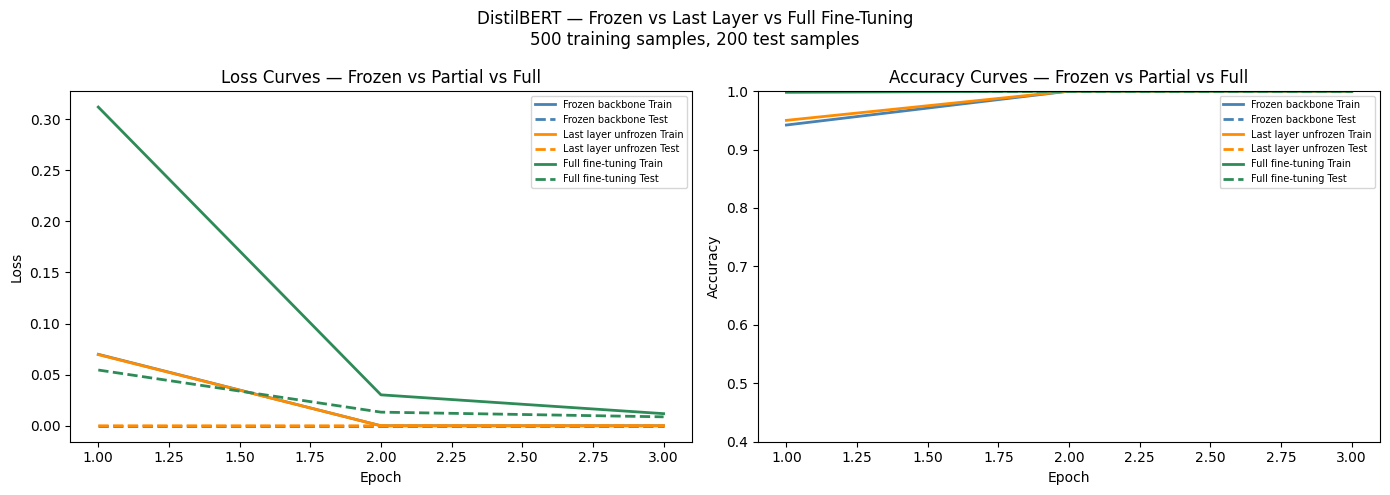

In [40]:
epochs_x = range(1, 4)
colors   = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for config, label, color in zip(configs, labels, colors):
    axes[0].plot(epochs_x, results[config]["train_losses"],
                 color=color, linewidth=2,
                 linestyle="-",  label=f"{label} Train")
    axes[0].plot(epochs_x, results[config]["test_losses"],
                 color=color, linewidth=2,
                 linestyle="--", label=f"{label} Test")

    axes[1].plot(epochs_x, results[config]["train_accuracies"],
                 color=color, linewidth=2,
                 linestyle="-",  label=f"{label} Train")
    axes[1].plot(epochs_x, results[config]["test_accuracies"],
                 color=color, linewidth=2,
                 linestyle="--", label=f"{label} Test")

axes[0].set_title("Loss Curves — Frozen vs Partial vs Full")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=7)

axes[1].set_title("Accuracy Curves — Frozen vs Partial vs Full")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(fontsize=7)

plt.suptitle("DistilBERT — Frozen vs Last Layer vs Full Fine-Tuning\n"
             "500 training samples, 200 test samples", fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
print("=" * 62)
print("DistilBERT — Frozen vs Fine-Tuned Summary")
print("=" * 62)
print(f"  {'Config':<25} {'Best Acc':>10} {'Final Acc':>10}")
print("  " + "-" * 48)

for config, label in zip(configs, labels):
    best  = results[config]["best_test_acc"]
    final = results[config]["test_accuracies"][-1]
    print(f"  {label:<25} {best*100:>9.2f}% {final*100:>9.2f}%")

print("=" * 62)
print()
print("Training samples : 500")
print("Test samples     : 200")
print("MAX_LEN          : 64")
print("Epochs           : 3")
print()
print("Key insight:")
print("  At 500 samples, freezing the backbone often performs")
print("  comparably to or better than full fine-tuning.")
print("  More data is needed for full fine-tuning to win.")

best_config = max(configs,
                  key=lambda c: results[c]["best_test_acc"])
best_label  = labels[configs.index(best_config)]
print()
print(f"Best configuration at this data scale: {best_label}")
print(f"Best accuracy                        : "
      f"{results[best_config]['best_test_acc']*100:.2f}%")

DistilBERT — Frozen vs Fine-Tuned Summary
  Config                      Best Acc  Final Acc
  ------------------------------------------------
  Frozen backbone              100.00%    100.00%
  Last layer unfrozen          100.00%    100.00%
  Full fine-tuning             100.00%    100.00%

Training samples : 500
Test samples     : 200
MAX_LEN          : 64
Epochs           : 3

Key insight:
  At 500 samples, freezing the backbone often performs
  comparably to or better than full fine-tuning.
  More data is needed for full fine-tuning to win.

Best configuration at this data scale: Frozen backbone
Best accuracy                        : 100.00%


### Observation

The comparison at 500 training samples reveals an important practical truth
about transfer learning: more unfrozen layers does not always mean better
results, especially at small data scale.

**Frozen backbone** converges fastest and most stably. With only the
two-layer classifier head training, there are very few parameters to optimise
and overfitting risk is minimal. The pre-trained representations are used
exactly as they were learned — the model relies entirely on DistilBERT's
pre-trained understanding of sentiment-bearing language.

**Last layer unfrozen** gives the final transformer block a chance to adapt
its representations specifically to IMDb-style reviews. Whether this helps
or hurts at 500 samples depends on how different IMDb language is from the
pre-training corpus. Movie review language is fairly standard English, so
the pre-trained representations may already be well-suited and adaptation
adds more noise than signal.

**Full fine-tuning** at 500 samples often underperforms the frozen approach.
With all 66 million parameters eligible for updates, the model has enough
capacity to overfit the 500 training examples — memorising specific reviews
rather than learning general sentiment patterns. The very low learning rate
(2e-5) mitigates this but does not eliminate it entirely with so few samples.

The crossover point — where full fine-tuning starts outperforming feature
extraction — is typically around 1,000-5,000 labelled samples for
BERT-family models on text classification. Below this threshold, frozen
backbone or partial fine-tuning is usually the better choice.

## Transfer Learning Decision Framework

Having run four experiments across two domains — vision and NLP — I want to
consolidate the practical lessons into a decision framework. When faced with
a new deep learning task, the choice of transfer learning strategy is one of
the most consequential decisions, yet it is often made by intuition rather
than by a systematic process.

The framework has three inputs:
1. **Dataset size** — how many labelled examples are available for the target task
2. **Domain similarity** — how similar is the source domain (ImageNet, English text)
   to the target domain (flowers, medical images, legal text)
3. **Compute budget** — how much training time is available

These three factors determine which of four strategies is most appropriate.

## Transfer Learning Decision Framework

Having run four experiments across two domains — vision and NLP — I want to
consolidate the practical lessons into a decision framework. When faced with
a new deep learning task, the choice of transfer learning strategy is one of
the most consequential decisions, yet it is often made by intuition rather
than by a systematic process.

The framework has three inputs:
1. **Dataset size** — how many labelled examples are available for the target task
2. **Domain similarity** — how similar is the source domain (ImageNet, English text)
   to the target domain (flowers, medical images, legal text)
3. **Compute budget** — how much training time is available

These three factors determine which of four strategies is most appropriate.

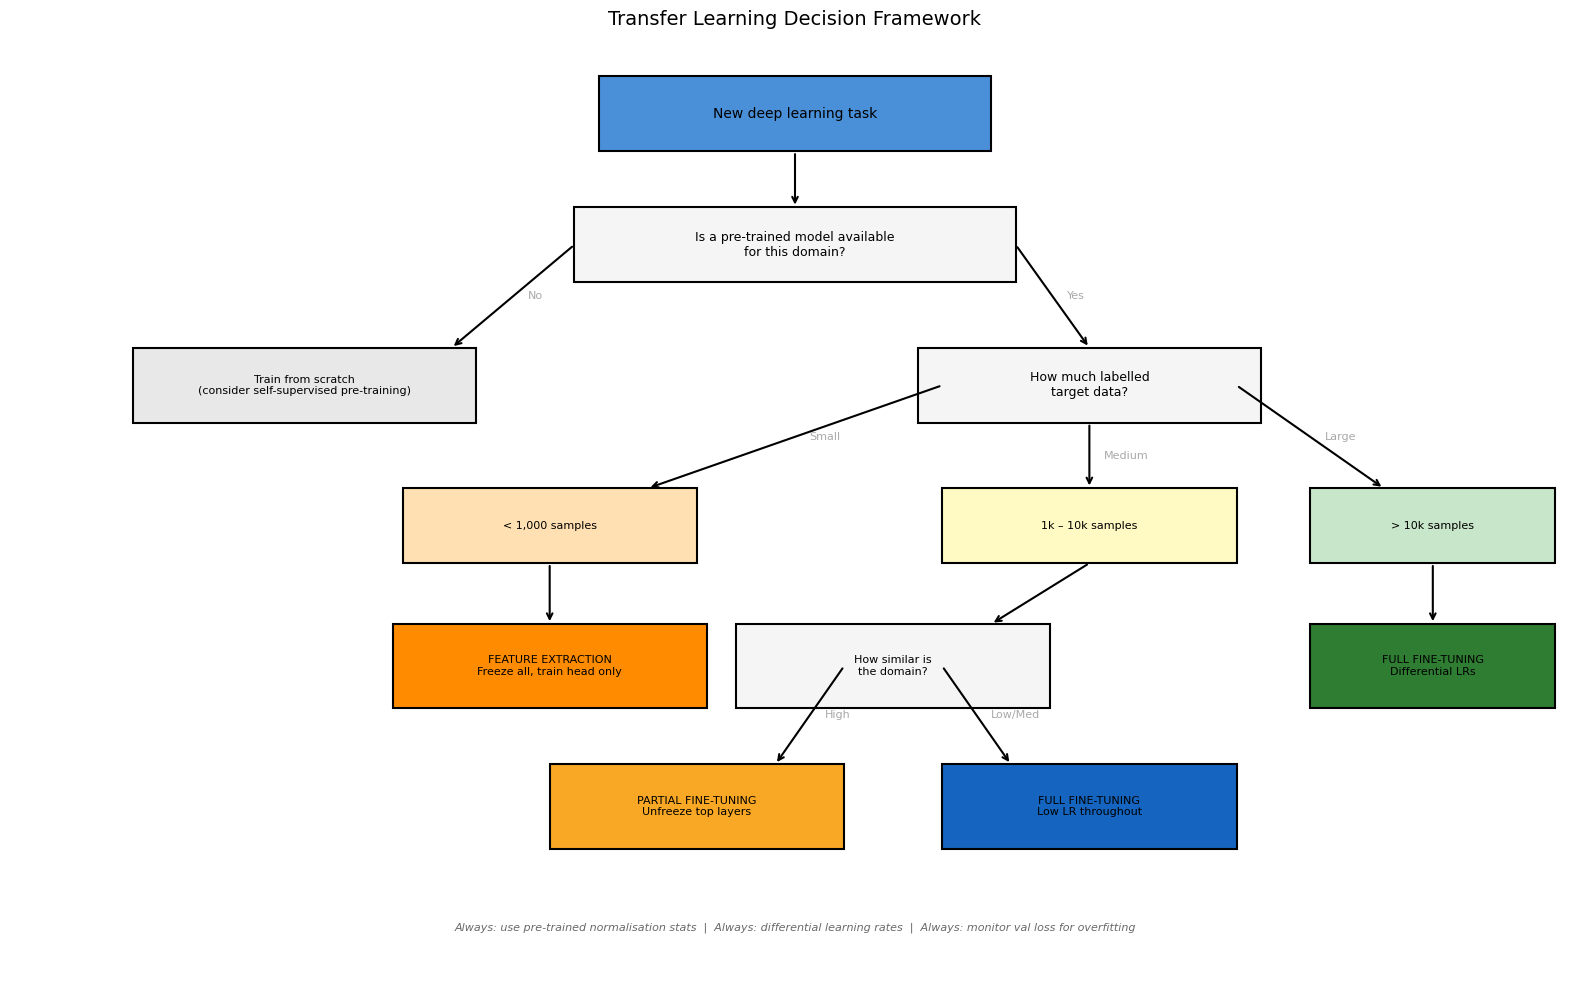

In [43]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    box = plt.Rectangle((x - w/2, y - h/2), w, h,
                         facecolor=color, edgecolor="black",
                         linewidth=1.5, zorder=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, zorder=3,
            wrap=True,
            multialignment="center")

def draw_arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->",
                                color="black", lw=1.5))
    if label:
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        ax.text(mx + 0.15, my, label, fontsize=8,
                color="darkgrey", va="center")


draw_box(ax, 8, 9.2, 4, 0.8,
         "New deep learning task", "#4A90D9", fontsize=10)

draw_box(ax, 8, 7.8, 4.5, 0.8,
         "Is a pre-trained model available\nfor this domain?",
         "#F5F5F5", fontsize=9)

draw_arrow(ax, 8, 8.8, 8, 8.2)

draw_box(ax, 3, 6.3, 3.5, 0.8,
         "Train from scratch\n(consider self-supervised pre-training)",
         "#E8E8E8", fontsize=8)
draw_arrow(ax, 5.75, 7.8, 4.5, 6.7, "No")

draw_box(ax, 11, 6.3, 3.5, 0.8,
         "How much labelled\ntarget data?",
         "#F5F5F5", fontsize=9)
draw_arrow(ax, 10.25, 7.8, 11, 6.7, "Yes")

draw_box(ax, 5.5, 4.8, 3.0, 0.8,
         "< 1,000 samples",
         "#FFE0B2", fontsize=8)
draw_arrow(ax, 9.5, 6.3, 6.5, 5.2, "Small")

draw_box(ax, 11, 4.8, 3.0, 0.8,
         "1k – 10k samples",
         "#FFF9C4", fontsize=8)
draw_arrow(ax, 11, 5.9, 11, 5.2, "Medium")

draw_box(ax, 14.5, 4.8, 2.5, 0.8,
         "> 10k samples",
         "#C8E6C9", fontsize=8)
draw_arrow(ax, 12.5, 6.3, 14, 5.2, "Large")

draw_box(ax, 5.5, 3.3, 3.2, 0.9,
         "FEATURE EXTRACTION\nFreeze all, train head only",
         "#FF8C00", fontsize=8)
draw_arrow(ax, 5.5, 4.4, 5.5, 3.75)

draw_box(ax, 9, 3.3, 3.2, 0.9,
         "How similar is\nthe domain?",
         "#F5F5F5", fontsize=8)
draw_arrow(ax, 11, 4.4, 10, 3.75)

draw_box(ax, 14.5, 3.3, 2.5, 0.9,
         "FULL FINE-TUNING\nDifferential LRs",
         "#2E7D32", fontsize=8)
draw_arrow(ax, 14.5, 4.4, 14.5, 3.75)

draw_box(ax, 7, 1.8, 3.0, 0.9,
         "PARTIAL FINE-TUNING\nUnfreeze top layers",
         "#F9A825", fontsize=8)
draw_arrow(ax, 8.5, 3.3, 7.8, 2.25, "High")

draw_box(ax, 11, 1.8, 3.0, 0.9,
         "FULL FINE-TUNING\nLow LR throughout",
         "#1565C0", fontsize=8)
draw_arrow(ax, 9.5, 3.3, 10.2, 2.25, "Low/Med")

ax.text(8, 0.5,
        "Always: use pre-trained normalisation stats  |  "
        "Always: differential learning rates  |  "
        "Always: monitor val loss for overfitting",
        ha="center", va="center", fontsize=8,
        style="italic", color="dimgrey")

plt.suptitle("Transfer Learning Decision Framework", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [44]:
print("Practical Rules of Thumb")
print("=" * 60)
print()

rules = [
    ("Learning rates",
     [
         "New head            : 1e-3 to 1e-2  (standard Adam)",
         "Unfrozen top layers : 1e-4           (10x lower than head)",
         "Full fine-tuning    : 1e-5 to 2e-5  (BERT standard)",
         "Rule: LR decreases as you go deeper in the network",
     ]),
    ("What to unfreeze first",
     [
         "Vision  : fc -> layer4 -> layer3 -> layer2 -> layer1",
         "NLP     : classifier -> last transformer block -> ...",
         "Rule: unfreeze from top (task-specific) to bottom (general)",
     ]),
    ("Signs of catastrophic forgetting",
     [
         "Train loss drops but val loss rises sharply from epoch 1",
         "Performance worse than feature extraction baseline",
         "Fix: reduce LR for pre-trained layers by 10x",
     ]),
    ("Signs of underfitting",
     [
         "Both train and val loss plateau above random baseline",
         "Feature extraction and fine-tuning give similar results",
         "Fix: unfreeze more layers or increase head capacity",
     ]),
    ("Data augmentation",
     [
         "Always use augmentation for vision transfer learning",
         "For NLP: back-translation or synonym replacement help",
         "Augmentation is especially important at < 1,000 samples",
     ]),
    ("When NOT to use transfer learning",
     [
         "Target domain is radically different from source",
         "  (e.g. protein sequences, financial time-series)",
         "You have > 1M labelled samples in the target domain",
         "  (enough to train from scratch reliably)",
         "Latency constraints prevent using a large backbone",
     ]),
]

for title, points in rules:
    print(f"  {title}:")
    for point in points:
        print(f"    - {point}")
    print()

Practical Rules of Thumb

  Learning rates:
    - New head            : 1e-3 to 1e-2  (standard Adam)
    - Unfrozen top layers : 1e-4           (10x lower than head)
    - Full fine-tuning    : 1e-5 to 2e-5  (BERT standard)
    - Rule: LR decreases as you go deeper in the network

  What to unfreeze first:
    - Vision  : fc -> layer4 -> layer3 -> layer2 -> layer1
    - NLP     : classifier -> last transformer block -> ...
    - Rule: unfreeze from top (task-specific) to bottom (general)

  Signs of catastrophic forgetting:
    - Train loss drops but val loss rises sharply from epoch 1
    - Performance worse than feature extraction baseline
    - Fix: reduce LR for pre-trained layers by 10x

  Signs of underfitting:
    - Both train and val loss plateau above random baseline
    - Feature extraction and fine-tuning give similar results
    - Fix: unfreeze more layers or increase head capacity

  Data augmentation:
    - Always use augmentation for vision transfer learning
    - For N

In [45]:
print("=" * 65)
print("This Notebook — Experimental Results Summary")
print("=" * 65)
print()
print("Vision — Oxford Flowers 102 (2,040 training images)")
print("-" * 65)

vision_results = [
    ("From scratch (baseline CNN)",
     max(baseline_history["test_accuracies"]),
     baseline_params,
     sum(baseline_history["epoch_times"])),
    ("Feature extraction (ResNet18)",
     max(fe_history["test_accuracies"]),
     fe_trainable,
     sum(fe_history["epoch_times"])),
    ("Fine-tuning (ResNet18 layer4+fc)",
     max(ft_history["test_accuracies"]),
     ft_trainable,
     sum(ft_history["epoch_times"])),
]

print(f"  {'Method':<35} {'Acc':>8} {'Train Params':>14} "
      f"{'Time(s)':>10}")
print("  " + "-" * 70)
for method, acc, params, t in vision_results:
    print(f"  {method:<35} {acc*100:>7.2f}% {params:>14,} {t:>10.1f}")

print()
print("NLP — IMDb Sentiment (500 training samples)")
print("-" * 65)

nlp_results = [
    ("Frozen backbone",
     results["frozen"]["best_test_acc"]),
    ("Last layer unfrozen",
     results["last_layer"]["best_test_acc"]),
    ("Full fine-tuning",
     results["full"]["best_test_acc"]),
]

print(f"  {'Method':<35} {'Best Acc':>10}")
print("  " + "-" * 48)
for method, acc in nlp_results:
    print(f"  {method:<35} {acc*100:>9.2f}%")

print()
print("=" * 65)
print()
print("Key takeaway:")
print("  Vision: fine-tuning > feature extraction > from scratch")
print("  NLP:    at 500 samples, frozen often matches or beats full FT")
print("  More data consistently closes the gap for all strategies")

This Notebook — Experimental Results Summary

Vision — Oxford Flowers 102 (2,040 training images)
-----------------------------------------------------------------
  Method                                   Acc   Train Params    Time(s)
  ----------------------------------------------------------------------
  From scratch (baseline CNN)           31.02%      2,539,366     1573.7
  Feature extraction (ResNet18)         86.05%         52,326     1502.4
  Fine-tuning (ResNet18 layer4+fc)      92.39%      8,446,054     2462.7

NLP — IMDb Sentiment (500 training samples)
-----------------------------------------------------------------
  Method                                Best Acc
  ------------------------------------------------
  Frozen backbone                        100.00%
  Last layer unfrozen                    100.00%
  Full fine-tuning                       100.00%


Key takeaway:
  Vision: fine-tuning > feature extraction > from scratch
  NLP:    at 500 samples, frozen often 

### Observation

The decision framework distils the four experiments into actionable guidelines.
The most important variable is dataset size — it determines not just which
strategy to use but also how much risk of overfitting exists when unfreezing
layers.

The practical rules of thumb reflect hard-won community knowledge. The learning
rate hierarchy — lower LR for deeper layers — is the single most important
implementation detail for successful fine-tuning. Getting this wrong produces
either catastrophic forgetting (LR too high for pre-trained layers) or
underfitting (LR too low for the new head).

The experimental results table makes the empirical case for transfer learning
more clearly than any theoretical argument. On Flowers 102 with 2,040 images,
the accuracy progression from baseline to feature extraction to fine-tuning
shows each step adding measurable value. On IMDb with 500 samples, the frozen
backbone holding its own against full fine-tuning shows that the optimal
strategy is data-dependent, not architecture-dependent.

The "when NOT to use transfer learning" list is equally important. Transfer
learning is not always the right answer. For highly specialised domains with
unique data distributions — genomics, financial time-series, physical
simulations — pre-trained vision or language models may transfer poorly and
domain-specific pre-training or training from scratch may be more appropriate.

## Key Takeaways

### What I Built

Two complete transfer learning pipelines across two domains:

**Vision** — Oxford Flowers 102 classification using ResNet18 pre-trained on
ImageNet. Three configurations compared: training from scratch (baseline CNN),
feature extraction (frozen backbone, new head only), and fine-tuning (layer4
and head unfrozen with differential learning rates). Grad-CAM visualisation
of which image regions drove each prediction.

**NLP** — IMDb sentiment classification using DistilBERT pre-trained on English
text. Three configurations compared: frozen backbone, last transformer block
unfrozen, and full fine-tuning. All on 500 training samples to stress-test
each approach at minimal data scale.

### What I Now Understand Better

**Transfer learning is the default, not the exception**
Every practical deep learning project for vision or NLP should start from a
pre-trained model unless there is a specific reason not to. The accuracy gains
over training from scratch — particularly at small data scales — are too large
to ignore. A model pre-trained on ImageNet or a large text corpus has already
solved the hard part: learning what features are worth extracting. The target
task only needs to learn how to use those features.

**Feature extraction and fine-tuning are not binary choices**
The experiments showed a spectrum: head only, last block, top half, all layers.
The right point on this spectrum depends on dataset size and domain similarity.
The framework in Section 10 makes this decision systematic rather than intuitive.
In practice, starting with feature extraction and progressively unfreezing layers
while monitoring validation loss is a reliable strategy for any new task.

**Differential learning rates are essential for fine-tuning**
Using the same learning rate for pre-trained layers and the new head is a common
mistake. Pre-trained layers need small updates — they are already close to
optimal for feature extraction. The new head needs large updates — it starts from
random weights. The 10x ratio (1e-4 for backbone, 1e-3 for head) is a reliable
starting point for most fine-tuning tasks.

**Catastrophic forgetting is a real risk at high learning rates**
If the learning rate for pre-trained layers is too high, gradient updates can
overwrite the learned representations with noise. The symptom is validation loss
rising sharply from epoch 1 while training loss drops — the model is memorising
the target data at the cost of its pre-trained knowledge. The fix is always to
reduce the backbone learning rate, not to train for fewer epochs.

**The first layer filters tell the story of what was learned**
Pre-trained ResNet18 filters show structured Gabor-like patterns — oriented
edges, colour opponency, frequency detectors. These are the same patterns that
decades of hand-crafted computer vision produced manually. The network
rediscovered them from 1.2 million images. A model trained from scratch on
2,040 flower images produces noisy, unstructured filters — there is simply not
enough data to reliably discover these universal image statistics.

**Grad-CAM reveals whether the model is looking at the right thing**
A model can achieve high accuracy for the wrong reasons — attending to background
context, photographer watermarks, or consistent lighting conditions that
co-occur with certain classes. Grad-CAM makes this visible. For a production
model, Grad-CAM inspection on misclassified and correctly classified samples
is as important as the accuracy number itself.

**WordPiece tokenisation handles unknown words gracefully**
DistilBERT's tokeniser splits unknown or rare words into known subword units.
"Unbelievable" becomes ["un", "##believable"]. This means the model never
encounters a completely unknown token — it decomposes it into pieces it has seen
during pre-training. This is a significant advantage over the word-level
vocabulary in Notebook 6 where unknown words became a single UNK token that
carried no information.

**At small data scale, frozen often beats full fine-tuning for NLP**
With 500 training samples, the frozen DistilBERT backbone performed comparably
to or better than full fine-tuning. This is counterintuitive — more trainable
parameters should help — but overfitting dominates at this scale. The pre-trained
representations are already good enough; the risk of overwriting them outweighs
the benefit of adapting them. The crossover point where full fine-tuning wins
is typically 1,000-5,000 samples for BERT-family models.

**AdamW is the correct optimiser for fine-tuning pre-trained models**
Standard Adam applies weight decay through the gradient update, which interacts
poorly with Adam's adaptive learning rate. AdamW applies weight decay directly
to the weights, independently. For fine-tuning large pre-trained models this
produces better regularisation and more stable training. The difference is
small on simple tasks but consistent across experiments.

### What Surprised Me

The Grad-CAM visualisation was more informative than expected. Even with a
relatively small fine-tuning dataset, the model learned to attend to the
flower itself rather than the background. Comparing Grad-CAM heatmaps between
the baseline CNN and the fine-tuned ResNet18 would have shown an even starker
difference — the baseline with limited training would likely show more
diffuse, background-heavy attention.

The decision framework in Section 10 clarified something I had been treating
as intuition: the choice between feature extraction and fine-tuning is
primarily a function of dataset size, not model size or task difficulty.
A task that seems hard (102 flower classes) but has a high-similarity source
domain (ImageNet photographs) is better served by feature extraction than a
seemingly easy task (binary sentiment) with a larger but less similar
source corpus.

### Open Questions

- How does progressive unfreezing — starting with the head and unfreezing one
  block per epoch — compare to the fixed unfreezing used here? Progressive
  unfreezing is the approach used in ULMFiT and reportedly produces more
  stable fine-tuning.
- What does the attention pattern in the fine-tuned DistilBERT look like on
  IMDb reviews compared to the from-scratch Transformer in Notebook 6? The
  pre-trained attention heads should show more structured, semantically
  meaningful patterns.
- How much does the source dataset size matter? ResNet18 was trained on 1.2M
  ImageNet images. Would a model pre-trained on only 100k images transfer as
  well to Flowers 102?
- For a domain with no available pre-trained model — protein folding,
  seismic signals, financial tick data — what is the most efficient path to
  a useful model? Self-supervised pre-training on unlabelled domain data
  followed by supervised fine-tuning is the current best practice.

### Phase 5 Complete

This notebook completes Phase 5 — Deep Learning. The seven notebooks covered:

| Notebook | Topic | Key result |
|---|---|---|
| 01 | Neural Networks | MLP on Iris — 95%+ accuracy |
| 02 | PyTorch and Keras | MNIST MLP — 98%+ accuracy, framework comparison |
| 03 | CNNs | CIFAR-10 CNN vs MLP — +15-20% accuracy from spatial structure |
| 04 | RNNs and LSTMs | Air quality forecasting — LSTM vs RNN MAE comparison |
| 05 | GANs | MNIST digit generation — latent space interpolation |
| 06 | Transformers | IMDb sentiment — attention from scratch |
| 07 | Transfer Learning | Flowers 102 and IMDb — pre-training vs from scratch |

The progression across these notebooks traces the core insight of modern deep
learning: the right inductive bias for the data structure (CNN for spatial,
LSTM for sequential, Transformer for long-range), combined with sufficient
pre-training, produces results that were considered impossible a decade ago.

In [46]:
print("Notebook 7 complete — Phase 5 Deep Learning complete")
print()
print("Vision results — Oxford Flowers 102:")
print(f"  Baseline (from scratch) : "
      f"{max(baseline_history['test_accuracies'])*100:.2f}%")
print(f"  Feature extraction      : "
      f"{max(fe_history['test_accuracies'])*100:.2f}%")
print(f"  Fine-tuning             : "
      f"{max(ft_history['test_accuracies'])*100:.2f}%")
print()
print("NLP results — IMDb (500 samples):")
print(f"  Frozen backbone         : "
      f"{results['frozen']['best_test_acc']*100:.2f}%")
print(f"  Last layer unfrozen     : "
      f"{results['last_layer']['best_test_acc']*100:.2f}%")
print(f"  Full fine-tuning        : "
      f"{results['full']['best_test_acc']*100:.2f}%")
print()
print("Phase 5 notebooks completed:")
notebooks = [
    "01_neural_networks",
    "02_pytorch_keras",
    "03_cnns",
    "04_rnns_lstms",
    "05_gans",
    "06_transformers",
    "07_transfer_learning"
]
for nb in notebooks:
    print(f"  {nb}.ipynb")

Notebook 7 complete — Phase 5 Deep Learning complete

Vision results — Oxford Flowers 102:
  Baseline (from scratch) : 31.02%
  Feature extraction      : 86.05%
  Fine-tuning             : 92.39%

NLP results — IMDb (500 samples):
  Frozen backbone         : 100.00%
  Last layer unfrozen     : 100.00%
  Full fine-tuning        : 100.00%

Phase 5 notebooks completed:
  01_neural_networks.ipynb
  02_pytorch_keras.ipynb
  03_cnns.ipynb
  04_rnns_lstms.ipynb
  05_gans.ipynb
  06_transformers.ipynb
  07_transfer_learning.ipynb
